# IIQ3402: Ayudantía 2

En esta ayudantía veremos los conceptos básicos del **Análisis Exploratorio de Datos.**


In [ ]:
# !pip install pandas -q
# !pip install numpy -q
# !pip install matplotlib -q
# !pip install seaborn -q
# !pip install pingouin -q

# Paquetes relevantes.

Para facilitar la transmición de información y utilización de `python` en sus proyectos futuros y el curso.

In [2]:
import pandas as pd # manipulacion de datos
import numpy as np # algebra y cosas asociadas
import matplotlib.pyplot as plt # graficos
from scipy import stats # estadistica básica
import seaborn as sns # graficos mas bonitos
import pingouin as pg # estadistica avanzada

# Netflix

In [7]:

link = 'https://github.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/SetDeDatos/netflix_titles.csv?raw=true'
netflix_df = pd.read_csv(link)
if 'Unnamed: 0' in netflix_df.columns: # para evitar errores si no existe la columna, 
    # más adelante no se pondrá para que aprendan a manejar estos casos.
    netflix_df = netflix_df.drop('Unnamed: 0', axis=1)
netflix_df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [8]:
netflix_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6234 entries, 0 to 6233
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       6234 non-null   int64 
 1   type          6234 non-null   object
 2   title         6234 non-null   object
 3   director      4265 non-null   object
 4   cast          5664 non-null   object
 5   country       5758 non-null   object
 6   date_added    6223 non-null   object
 7   release_year  6234 non-null   int64 
 8   rating        6224 non-null   object
 9   duration      6234 non-null   object
 10  listed_in     6234 non-null   object
 11  description   6234 non-null   object
dtypes: int64(2), object(10)
memory usage: 584.6+ KB


In [9]:
netflix_df.describe()

,show_id,release_year
count,6.234000e+03,6234.00000
mean,7.670368e+07,2013.35932
std,1.094296e+07,8.81162
min,2.477470e+05,1925.00000
25%,8.003580e+07,2013.00000
50%,8.016337e+07,2016.00000
75%,8.024489e+07,2018.00000
max,8.123573e+07,2020.00000


In [4]:
# P1

movies = netflix_df[netflix_df['type'] == 'Movie']
movies.loc[:,'duration'] = movies['duration'].str.replace(' min', '').astype(int)

movies.sort_values(by='duration', ascending=False)[['type', 'title', 'duration']].head(10)


,type,title,duration
4315,Movie,Black Mirror: Bandersnatch,312
4227,Movie,Sangam,228
4106,Movie,Lagaan,224
870,Movie,Jodhaa Akbar,214
1100,Movie,The Irishman,209
635,Movie,The Gospel of Luke,205
5003,Movie,What's Your Raashee?,203
3580,Movie,The Lord of the Rings: The Return of the King,201
1360,Movie,Doctor Zhivago,200
4872,Movie,Elephants Dream 4 Hour,196


In [61]:
# P2
cat_movies = []
for i in netflix_df.index:
    descripcion_i = netflix_df.loc[i, 'description'].lower()
    if 'cat' in descripcion_i:
        cat_movies.append(netflix_df.loc[i, 'title'])
cat_movies

['Krish Trish and Baltiboy',
 'Krish Trish and Baltiboy: Best Friends Forever',
 'Krish Trish and Baltiboy: Oversmartness Never Pays',
 'Rolling Papers',
 'Frequency',
 'Adam Ruins Everything',
 'Lovesick',
 'Long Shot',
 'Two Catalonias',
 'Teach Us All',
 'China Salesman',
 'Gaga: Five Foot Two',
 'Criminal: France',
 'The Bund',
 'Bitcoin Heist',
 'Vincent N Roxxy',
 'As Above, So Below',
 'Al Hayba',
 'Arisan 2',
 'For the Birds',
 'Open Season',
 'The CEO',
 'Uncle Naji in UAE',
 'Garbage',
 'The River Wild',
 'The Year of Happiness and Love',
 'After',
 'StoryBots Super Songs',
 'The Haunting of Molly Hartley',
 '14 Cameras',
 'It Takes a Lunatic',
 'Nailed It! France',
 'Nailed It! Spain',
 'Kitten Rescuers',
 'Joe Rogan: Strange Times',
 'Illang: The Wolf Brigade',
 'S Storm',
 'In My Country',
 'Unnatural Selection',
 'Patton Oswalt: Annihilation',
 'Anthony Jeselnik: Thoughts and Prayers',
 'Aisa Yeh Jahaan',
 'Macchli Jal Ki Rani Hai',
 'Money',
 'Sardaarji 2',
 'Teshan',
 '

In [62]:
netflix_df['listed_in']

0                      Children & Family Movies, Comedies
1                                         Stand-Up Comedy
2                                                Kids' TV
3                                                Kids' TV
4                                                Comedies
                              ...                        
6229    TV Action & Adventure, TV Comedies, TV Sci-Fi ...
6230                                          TV Comedies
6231                                               Movies
6232             British TV Shows, TV Comedies, TV Dramas
6233                       Classic & Cult TV, TV Comedies
Name: listed_in, Length: 6234, dtype: object

In [70]:
# P3
index_musicales = []
for i in netflix_df.index:
    descripcion_i = netflix_df.loc[i, 'listed_in'].lower()
    if 'musical' in descripcion_i:
        index_musicales.append(i)
musicales = netflix_df.loc[index_musicales, :]

index_noUSA = []
for i in netflix_df.index:
    if netflix_df.loc[i, 'country'] != 'United States':
        index_noUSA.append(i)

noUSA = netflix_df.loc[index_noUSA, :]


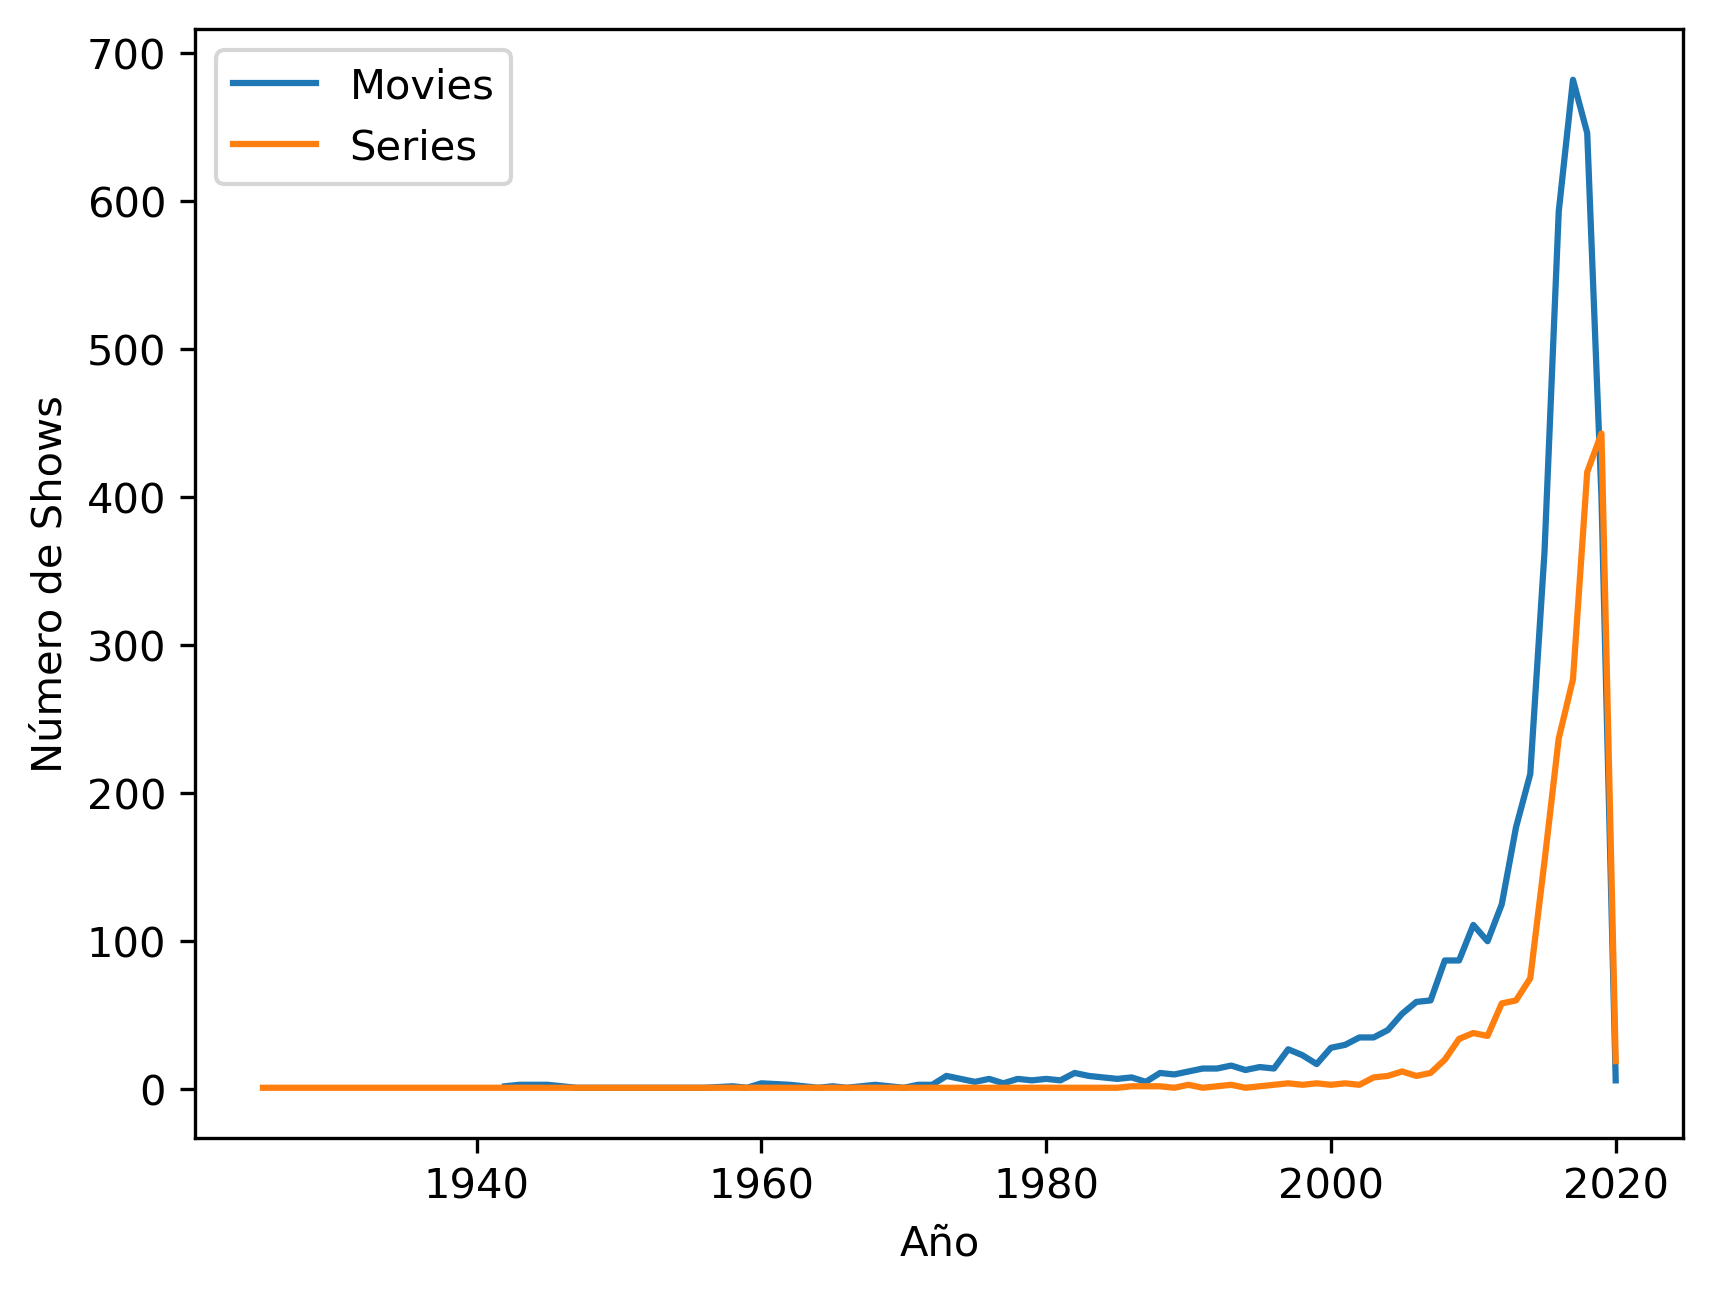

In [73]:
# P4

series = netflix_df[netflix_df['type'] == 'TV Show'] # obtenemos las vistas de día
# notar que movies viene de antes
movies_count = movies.groupby('release_year').count() # agrupamos y contamos cuantos hay por año
series_count = series.groupby('release_year').count() # agrupamos y contamos cuantos hay por año
# Si ven los dataframes quedan agrupados por año en el índice del DataFrame
# graficamos
fig, ax = plt.subplots(dpi = 300)
ax.plot(movies_count.index, movies_count['show_id'], label='Movies')
ax.plot(series_count.index, series_count['show_id'], label='Series')
ax.set_xlabel('Año')
ax.set_ylabel('Número de Shows')
ax.legend()
fig.savefig('figures/netflix_shows_by_year.pdf', transparent=True)
plt.show()

# VideoJuegos

## P1

In [8]:
link = 'https://github.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/SetDeDatos/Video_Game_Sales_as_of_Jan_2017.csv?raw=true'
vj_df = pd.read_csv(link)
if 'Unnamed: 0' in vj_df.columns:
    vj_df = vj_df.drop('Unnamed: 0', axis=1)
vj_df.head(5)

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.54,76.0,51.0,8.0,324.0,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.80,3.79,3.29,35.57,82.0,73.0,8.3,712.0,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.95,3.28,2.95,32.78,80.0,73.0,8.0,193.0,E
4,Pokemon Red/Pokemon Blue,G,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN


In [9]:

vj_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17416 non-null  object 
 1   Platform         17416 non-null  object 
 2   Year_of_Release  17408 non-null  float64
 3   Genre            17416 non-null  object 
 4   Publisher        17415 non-null  object 
 5   NA_Sales         17416 non-null  float64
 6   EU_Sales         17416 non-null  float64
 7   JP_Sales         17416 non-null  float64
 8   Other_Sales      17416 non-null  float64
 9   Global_Sales     17416 non-null  float64
 10  Critic_Score     8336 non-null   float64
 11  Critic_Count     8336 non-null   float64
 12  User_Score       7798 non-null   float64
 13  User_Count       7798 non-null   float64
 14  Rating           10252 non-null  object 
dtypes: float64(10), object(5)
memory usage: 2.0+ MB


In [10]:
vj_df.describe()

,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count
count,17408.000000,17416.000000,17416.000000,17416.000000,17416.000000,17416.000000,8336.000000,8336.000000,7798.000000,7798.000000
mean,2006.630859,0.254534,0.140727,0.075020,0.045908,0.516469,68.912548,26.192059,7.117056,162.672480
std,5.901598,0.800673,0.497341,0.303412,0.183932,1.526124,13.964937,18.991526,1.502410,562.837954
min,1976.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,0.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.050000,60.000000,11.000000,6.400000,10.000000
50%,2008.000000,0.070000,0.020000,0.000000,0.010000,0.160000,71.000000,21.000000,7.500000,25.000000
75%,2011.000000,0.230000,0.100000,0.030000,0.030000,0.450000,79.000000,36.000000,8.200000,81.000000
max,2017.000000,41.360000,28.960000,10.220000,10.570000,82.540000,98.000000,113.000000,9.700000,10766.000000


In [11]:
vj_df.groupby('Platform').describe()

Year_of_Release                                                 \
                   count         mean       std     min     25%     50%   
Platform                                                                  
2600               133.0  1981.827068  2.397951  1976.0  1981.0  1981.0   
3DO                  3.0  1994.666667  0.577350  1994.0  1994.5  1995.0   
3DS                553.0  2013.157324  1.726453  2005.0  2012.0  2013.0   
DC                  52.0  1999.942308  1.808623  1998.0  1999.0  2000.0   
DS                2249.0  2008.211650  1.763264  1985.0  2007.0  2008.0   
G                   98.0  1995.969388  4.157850  1988.0  1992.0  1997.0   
GBA                844.0  2003.241706  1.494431  2000.0  2002.0  2003.0   
GC                 563.0  2003.388988  1.387419  2001.0  2002.0  2003.0   
GEN                 27.0  1993.037037  1.091276  1990.0  1992.0  1993.0   
GG                   1.0  1992.000000       NaN  1992.0  1992.0  1992.0   
N64                319.0  1998.557994  1.330197  1996.0  1998.0  1999.0   
NES                 98.0  1987.153061  2.793040  1983.0  1985.0  1986.5   
NG                  12.0  1994.500000  1.000000  1993.0  1994.0  1994.5   
PC                1128.0  2009.037234  4.600301  1985.0  2007.0  2010.0   
PCFX                 1.0  1996.000000       NaN  1996.0  1996.0  1996.0   
PS                1200.0  1998.016667  1.848667  1994.0  1997.0  1998.0   
PS2               2206.0  2004.647325  2.592998  2000.0  2002.0  2005.0   
PS3               1362.0  2010.856094  2.458740  2006.0  2009.0  2011.0   
PS4                424.0  2015.207547  0.866688  2013.0  2015.0  2015.0   
PSP               1302.0  2008.820276  2.470416  2004.0  2007.0  2009.0   
PSV                502.0  2014.290837  1.474695  2008.0  2013.0  2015.0   
SAT                173.0  1996.028902  1.291420  1994.0  1995.0  1996.0   
SCD                  6.0  1993.833333  0.408248  1993.0  1994.0  1994.0   
SNES               239.0  1993.845188  1.679426  1990.0  1993.0  1994.0   
TG16                 2.0  1995.000000  0.000000  1995.0  1995.0  1995.0   
WS                   7.0  2000.285714  1.112697  1999.0  1999.5  2000.0   
Wii               1357.0  2008.971997  1.554074  2006.0  2008.0  2009.0   
WiiU               153.0  2013.712418  1.296114  2012.0  2013.0  2014.0   
X                  833.0  2003.629052  1.371226  2000.0  2003.0  2004.0   
X360              1297.0  2009.902082  2.474026  2005.0  2008.0  2010.0   
XOne               264.0  2015.015152  0.955153  2013.0  2014.0  2015.0   

                         NA_Sales            ... User_Score      User_Count  \
             75%     max    count      mean  ...        75%  max      count   
Platform                                     ...                              
2600      1982.0  1992.0    133.0  0.681203  ...        NaN  NaN        0.0   
3DO       1995.0  1995.0      3.0  0.000000  ...        NaN  NaN        0.0   
3DS       2015.0  2016.0    553.0  0.158318  ...      7.900  9.6      179.0   
DC        2000.0  2008.0     52.0  0.104423  ...      9.075  9.4       14.0   
DS        2009.0  2014.0   2251.0  0.170253  ...      8.000  9.5      521.0   
G         2000.0  2001.0     98.0  1.166531  ...        NaN  NaN        0.0   
GBA       2004.0  2007.0    844.0  0.222310  ...      8.600  9.6      265.0   
GC        2005.0  2007.0    563.0  0.237176  ...      8.500  9.4      373.0   
GEN       1994.0  1994.0     27.0  0.713704  ...        NaN  NaN        0.0   
GG        1992.0  1992.0      1.0  0.000000  ...        NaN  NaN        0.0   
N64       1999.0  2008.0    319.0  0.435799  ...        NaN  NaN        0.0   
NES       1989.0  1994.0     98.0  1.285102  ...        NaN  NaN        0.0   
NG        1995.0  1996.0     12.0  0.000000  ...        NaN  NaN        0.0   
PC        2012.0  2016.0   1128.0  0.084734  ...      8.200  9.3      859.0   
PCFX      1996.0  1996.0      1.0  0.000000  ...        NaN  NaN        0.0   
PS        1999.0  2003.0   1200.0  0

### P1 a

In [88]:
# P1 a - Medidas descriptivas de Global_Sales agrupadas por Platform
glob_sales = vj_df.groupby('Platform')['Global_Sales'].describe()
glob_sales['IQR'] = glob_sales['75%'] - glob_sales['25%']
glob_sales['Rango'] = glob_sales['max'] - glob_sales['min']
glob_sales['Mean - Median'] = np.round(glob_sales['mean'] - glob_sales['50%'], 5)
glob_sales.sort_values(by='Mean - Median', ascending=False)
display(glob_sales)

,count,mean,std,min,25%,50%,75%,max,IQR,Rango,Mean - Median
Platform,,,,,,,,,,,
2600,133.0,0.729925,0.917241,0.07,0.2900,0.460,0.7800,7.81,0.4900,7.74,0.26992
3DO,3.0,0.033333,0.023094,0.02,0.0200,0.020,0.0400,0.06,0.0200,0.04,0.01333
3DS,553.0,0.489946,1.465103,0.01,0.0400,0.110,0.3200,14.92,0.2800,14.91,0.37995
DC,52.0,0.307115,0.469912,0.02,0.0775,0.135,0.2975,2.42,0.2200,2.40,0.17212
DS,2251.0,0.359343,1.396752,0.01,0.0400,0.100,0.2600,29.81,0.2200,29.80,0.25934
G,98.0,2.606633,5.365287,0.06,0.3025,1.165,2.1650,31.37,1.8625,31.31,1.44163
GBA,844.0,0.377630,0.886786,0.01,0.0500,0.160,0.3800,15.85,0.3300,15.84,0.21763
GC,563.0,0.354227,0.682301,0.01,0.0700,0.150,0.3500,7.07,0.2800,7.06,0.20423
GEN,27.0,1.050370,1.492217,0.03,0.0700,0.150,1.7100,6.03,1.6400,6.00,0.90037


### P1 b

In [93]:
# P1 b - Medidas descriptivas de User_Score agrupadas por Genre
us_score = vj_df.groupby('Genre')['User_Score'].describe()
us_score['IQR'] = us_score['75%'] - us_score['25%']
us_score['Rango'] = us_score['max'] - us_score['min']
us_score['Mean - Median'] = np.round(us_score['mean'] - us_score['50%'], 5)
us_score.sort_values(by='Mean - Median', ascending=False)

,count,mean,std,min,25%,50%,75%,max,IQR,Rango,Mean - Median
Genre,,,,,,,,,,,
Role-Playing,766.0,7.602872,1.103277,1.4,7.00,7.80,8.4,9.7,1.40,8.3,-0.19713
Misc,446.0,6.823991,1.540213,0.5,6.00,7.10,8.0,9.2,2.00,8.7,-0.27601
Racing,653.0,7.003216,1.560490,0.3,6.20,7.30,8.2,9.3,2.00,9.0,-0.29678
Fighting,409.0,7.302689,1.389268,0.9,6.60,7.60,8.3,9.2,1.70,8.3,-0.29731
Puzzle,135.0,7.180000,1.535150,1.1,6.35,7.50,8.2,9.5,1.85,8.4,-0.32000
Action,1878.0,7.049894,1.429821,0.3,6.30,7.40,8.0,9.5,1.70,9.2,-0.35011
Shooter,945.0,7.023069,1.530633,1.2,6.30,7.40,8.1,9.3,1.80,8.1,-0.37693
Simulation,358.0,7.128212,1.623346,1.7,6.50,7.55,8.3,9.6,1.80,7.9,-0.42179
Platform,435.0,7.276322,1.540248,0.2,6.50,7.70,8.4,9.4,1.90,9.2,-0.42368


## P2

### P2 a

/var/folders/n8/t936zpy50cn66sdv0cwd2c5r0000gn/T/ipykernel_26973/2719886992.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('viridis', n_plats)


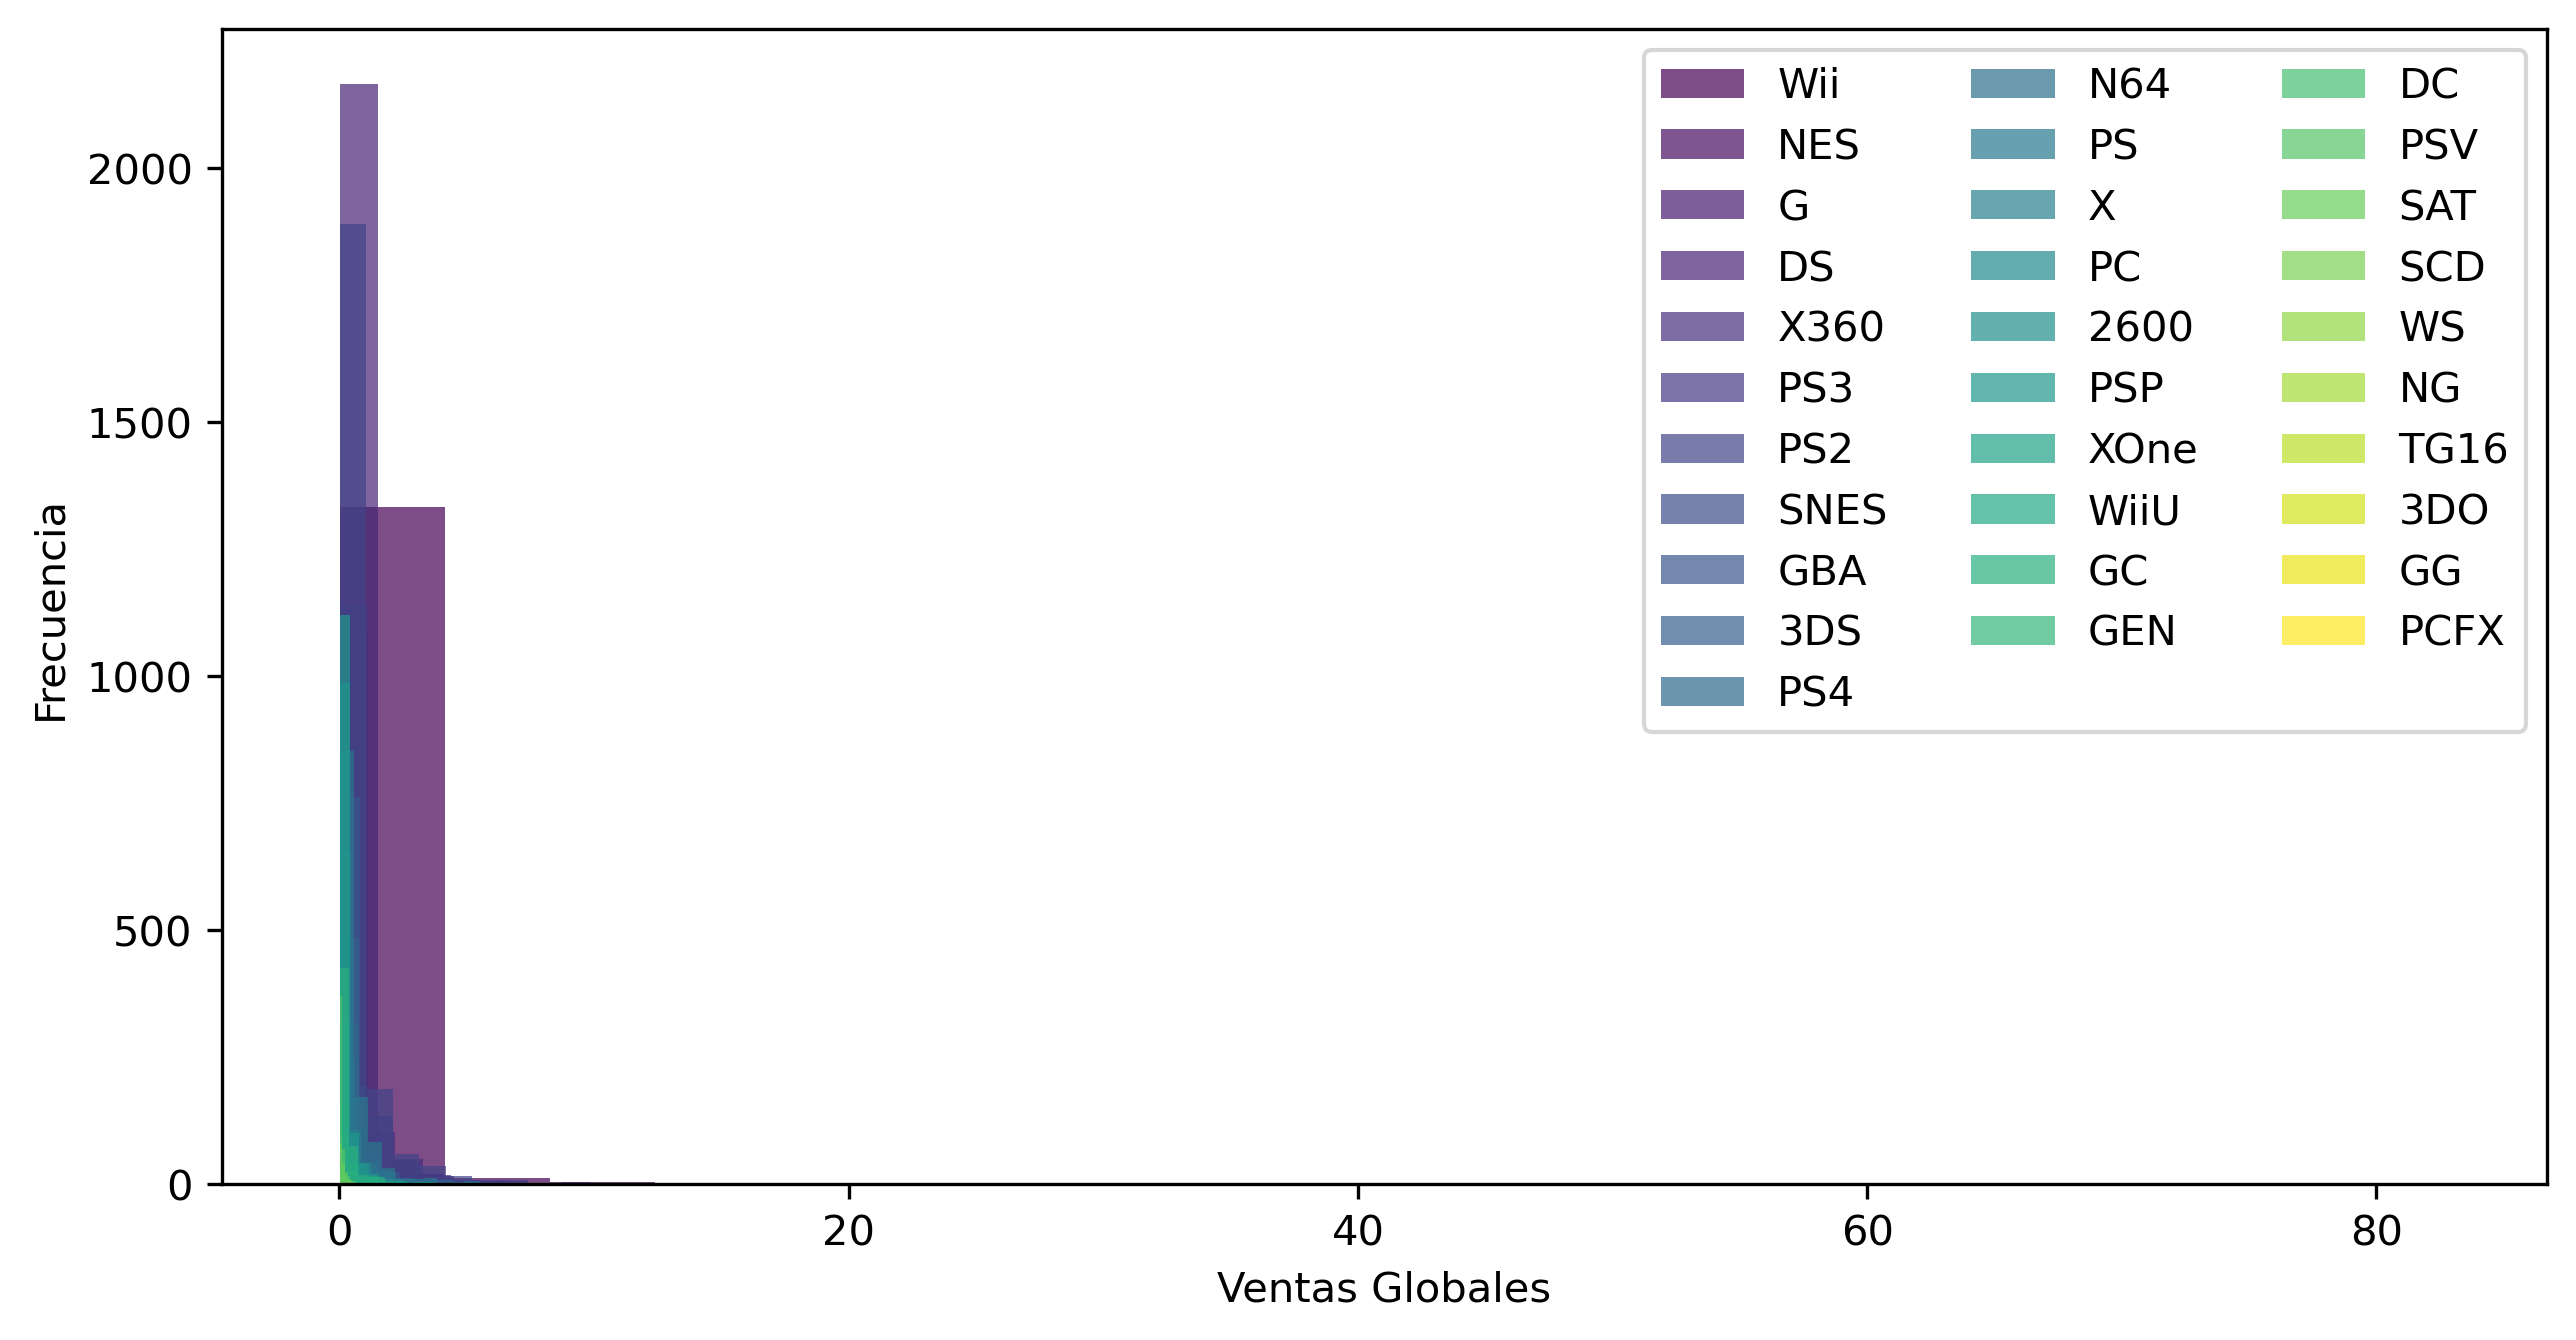

In [111]:
# P2
# a
global_sales_platform = vj_df[['Global_Sales','Platform']]

n_plats = len(global_sales_platform['Platform'].unique())
fig, ax = plt.subplots(dpi = 300, figsize = (10,5))
color_map = plt.cm.get_cmap('viridis', n_plats)
for i, genre in enumerate(global_sales_platform['Platform'].unique()):
    genre_df = global_sales_platform[global_sales_platform['Platform'] == genre]
    ax.hist(genre_df['Global_Sales'], label = genre, alpha = 0.7, bins = 20, color = color_map(i))
ax.set_xlabel('Ventas Globales')
ax.set_ylabel('Frecuencia')
ax.legend(ncol = 3)
fig.savefig('figures/global_sales_by_platform_hist.pdf', transparent=True)
plt.show()



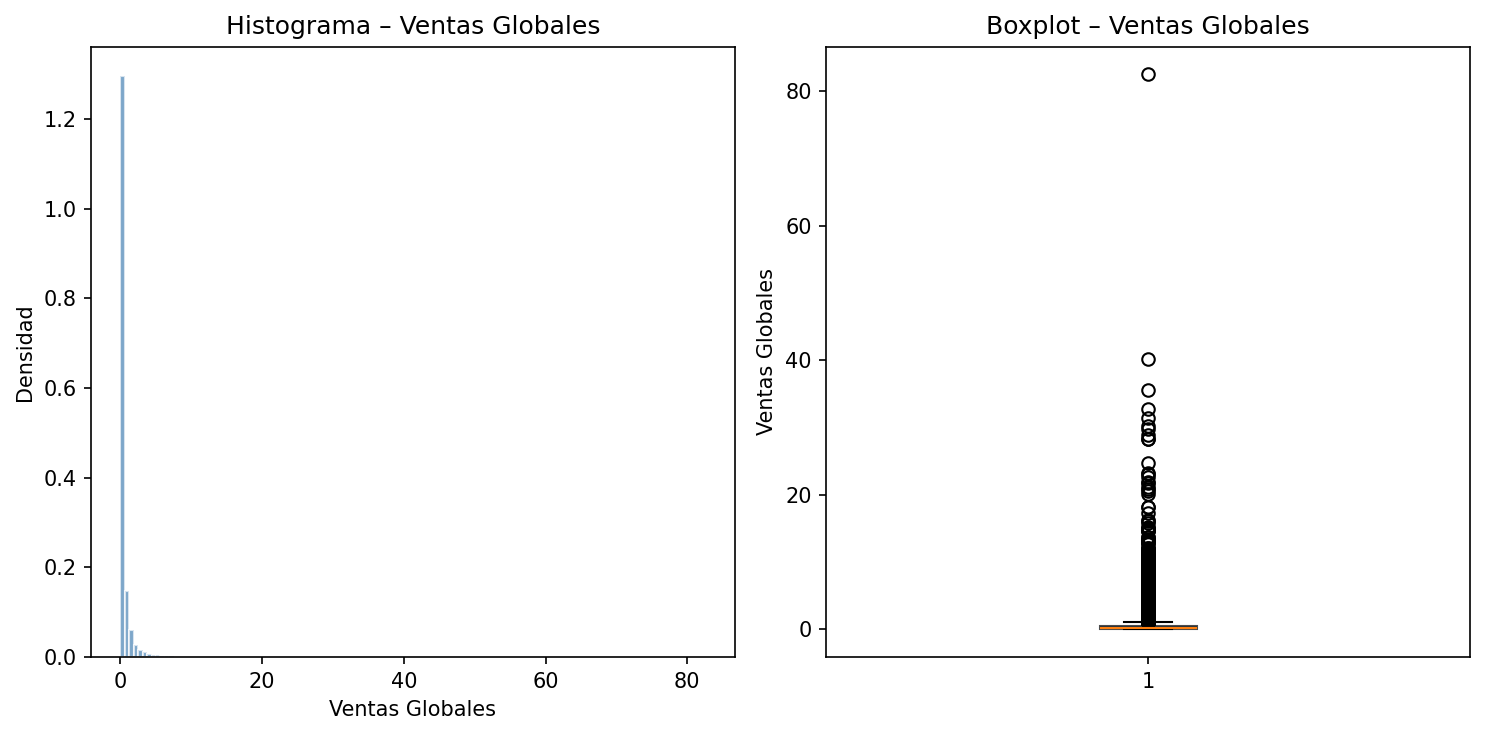

In [15]:
# P2 a - Histograma + Boxplot de Global_Sales (sin agrupar)
data = vj_df['Global_Sales'].dropna()

fig, ax = plt.subplots(1, 2, figsize=(10, 5), dpi=150)

# Histograma
n_bins = int(np.sqrt(len(data)))
ax[0].hist(data, bins=n_bins, alpha=0.7, color='steelblue', density=True, edgecolor='white')
ax[0].set_xlabel('Ventas Globales')
ax[0].set_ylabel('Densidad')
ax[0].set_title('Histograma – Ventas Globales')

# Boxplot
ax[1].boxplot(data, patch_artist=True,
              boxprops=dict(facecolor='steelblue', alpha=0.7))
ax[1].set_ylabel('Ventas Globales')
ax[1].set_title('Boxplot – Ventas Globales')

fig.tight_layout()
plt.show()

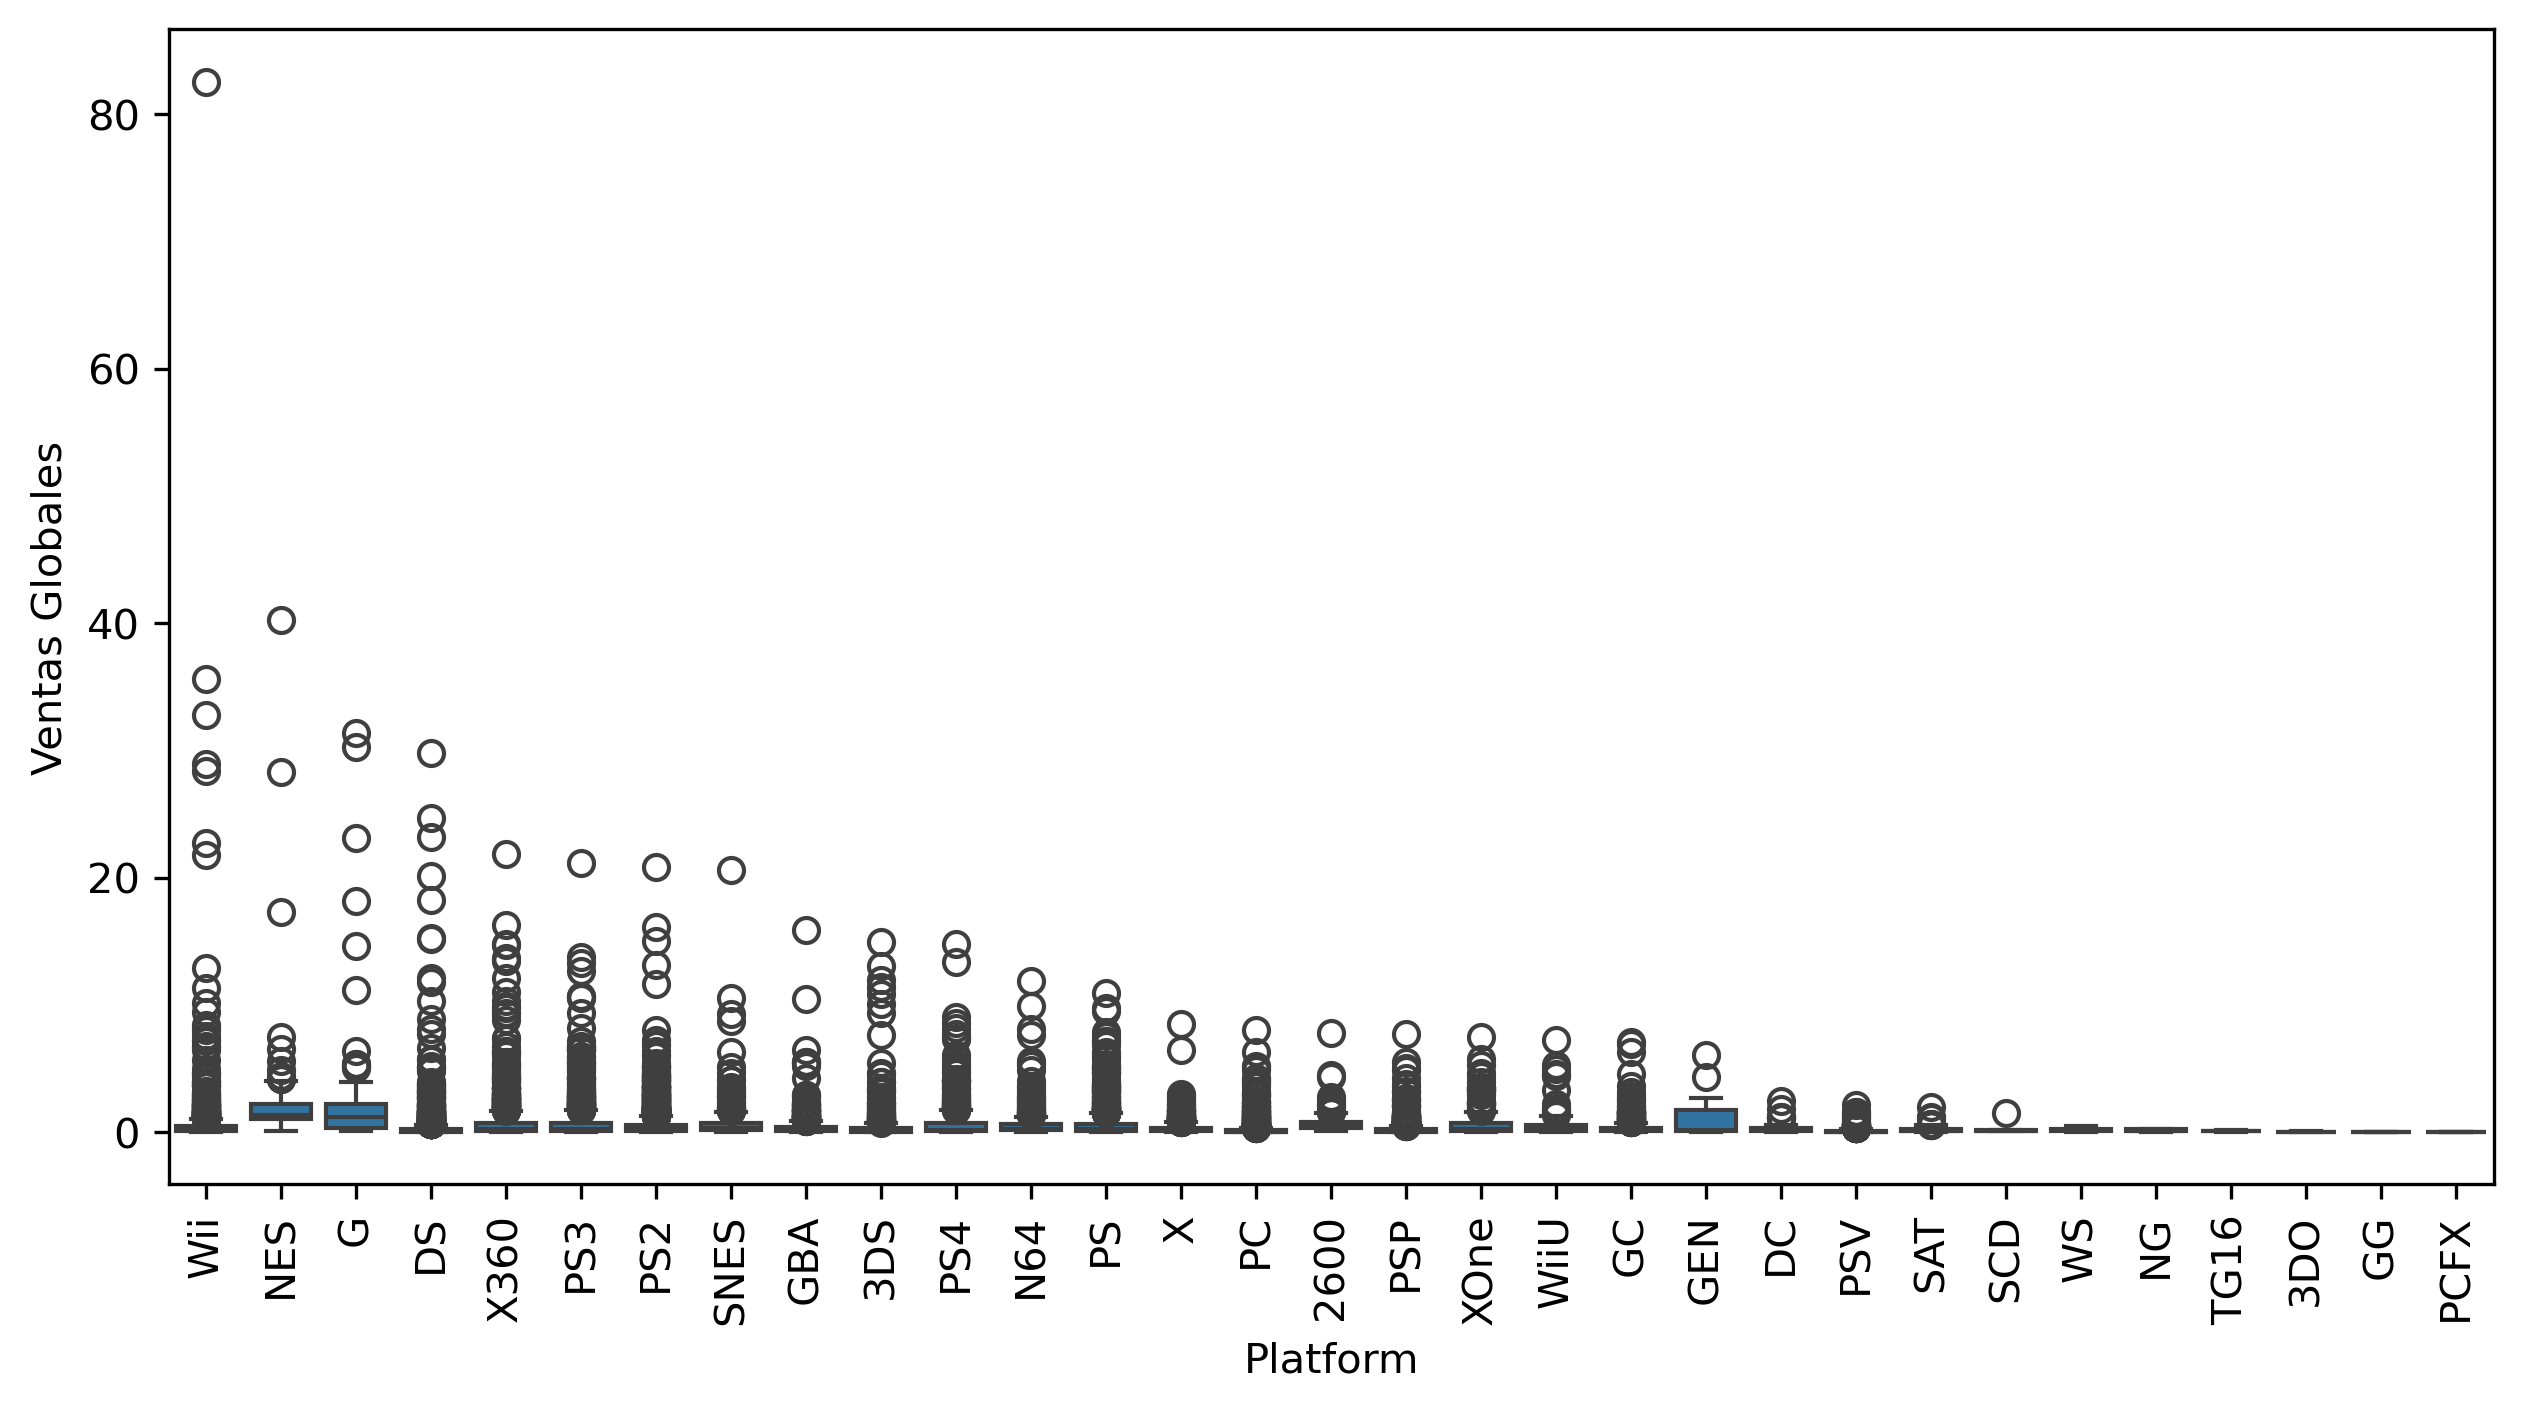

In [ ]:
# P2
# a
glob = vj_df[['Platform','Global_Sales']]
fig, ax = plt.subplots(dpi = 300, figsize = (10,5))
sns.boxplot(glob, x = 'Platform', y = 'Global_Sales', ax = ax, orient = 'v')
ax.set_xlabel('Platform')
ax.set_ylabel('Ventas Globales')
plt.xticks(rotation = 90)
fig.savefig('figures/global_sales_by_platform_box.pdf', transparent=True)
plt.show()

### P2 b

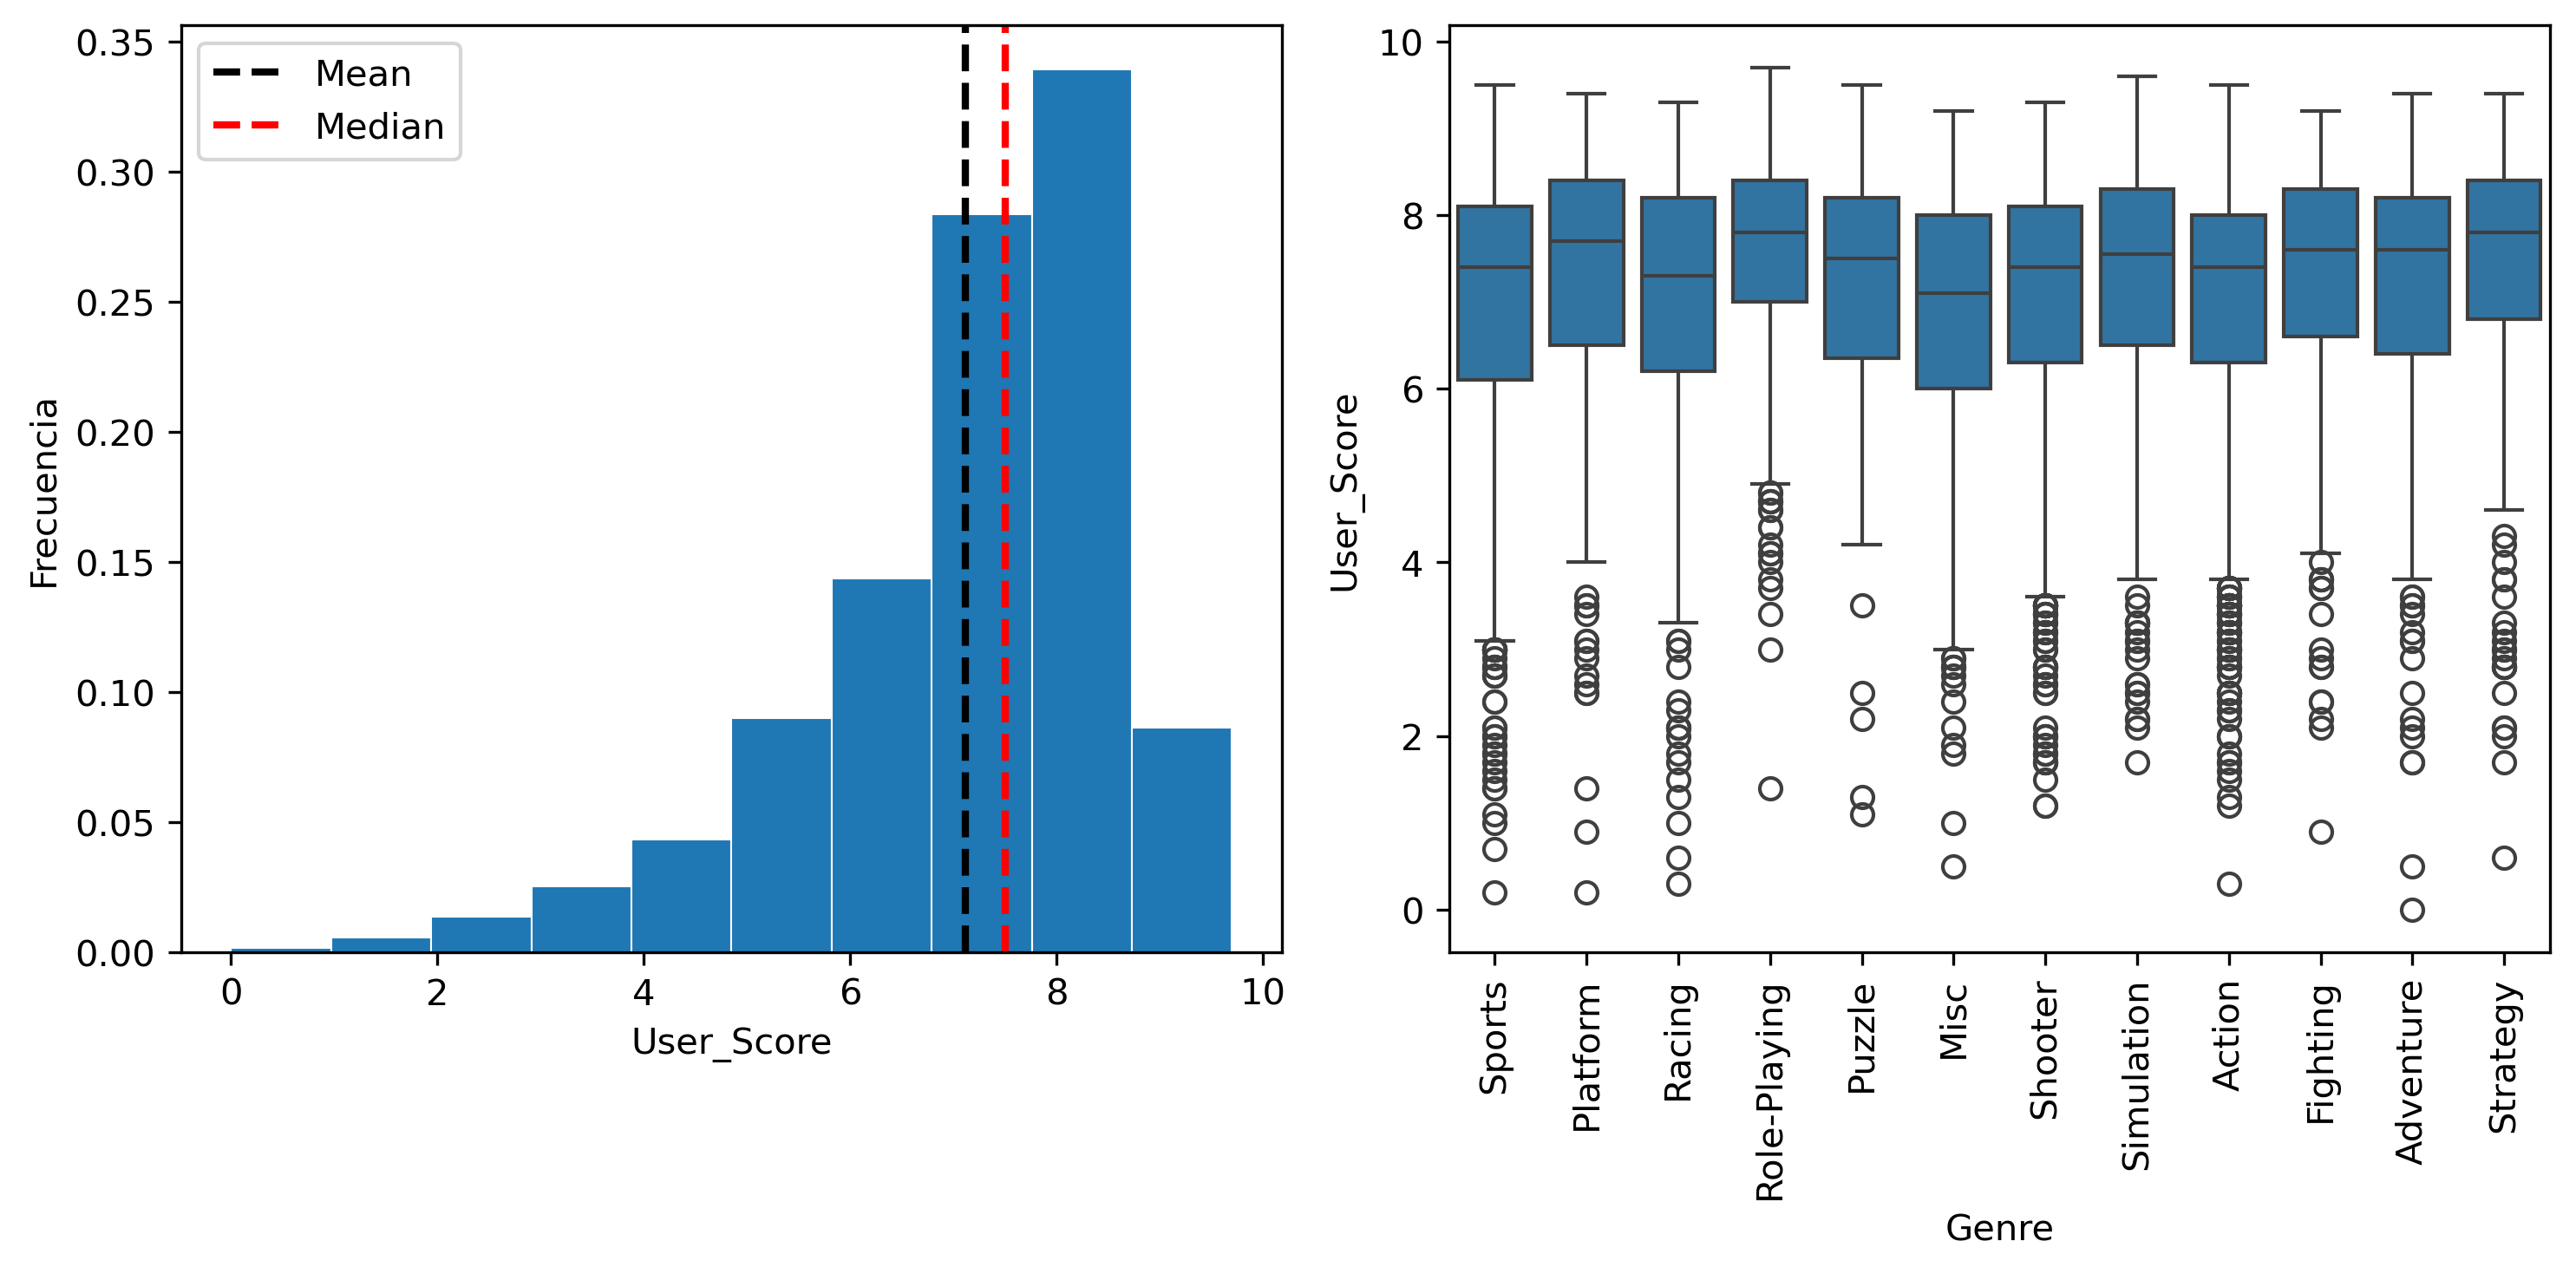

In [113]:
# P2
# b
user_genre = vj_df[['Genre','User_Score']]
fig, ax = plt.subplots(1,2,dpi = 300, figsize = (10,5))
ax[0].hist(user_genre['User_Score'], density = True, linewidth=0.5, edgecolor="white")
ax[0].set_xlabel('User_Score')
ax[0].set_ylabel('Frecuencia')
mean_score = user_genre['User_Score'].mean()
ax[0].axvline(mean_score, color='k', linestyle='dashed', linewidth=2, label = 'Mean')
median_score = user_genre['User_Score'].median()
ax[0].axvline(median_score, color='r', linestyle='dashed', linewidth=2, label = 'Median')
ax[0].legend()
sns.boxplot(user_genre, x = 'Genre', y = 'User_Score', ax = ax[1], orient = 'v')
ax[1].set_xlabel('Genre')
ax[1].set_ylabel('User_Score')
plt.xticks(rotation = 90)
fig.tight_layout()
fig.savefig('figures/user_score_by_genre.pdf', transparent=True)
plt.show()


### P2 c

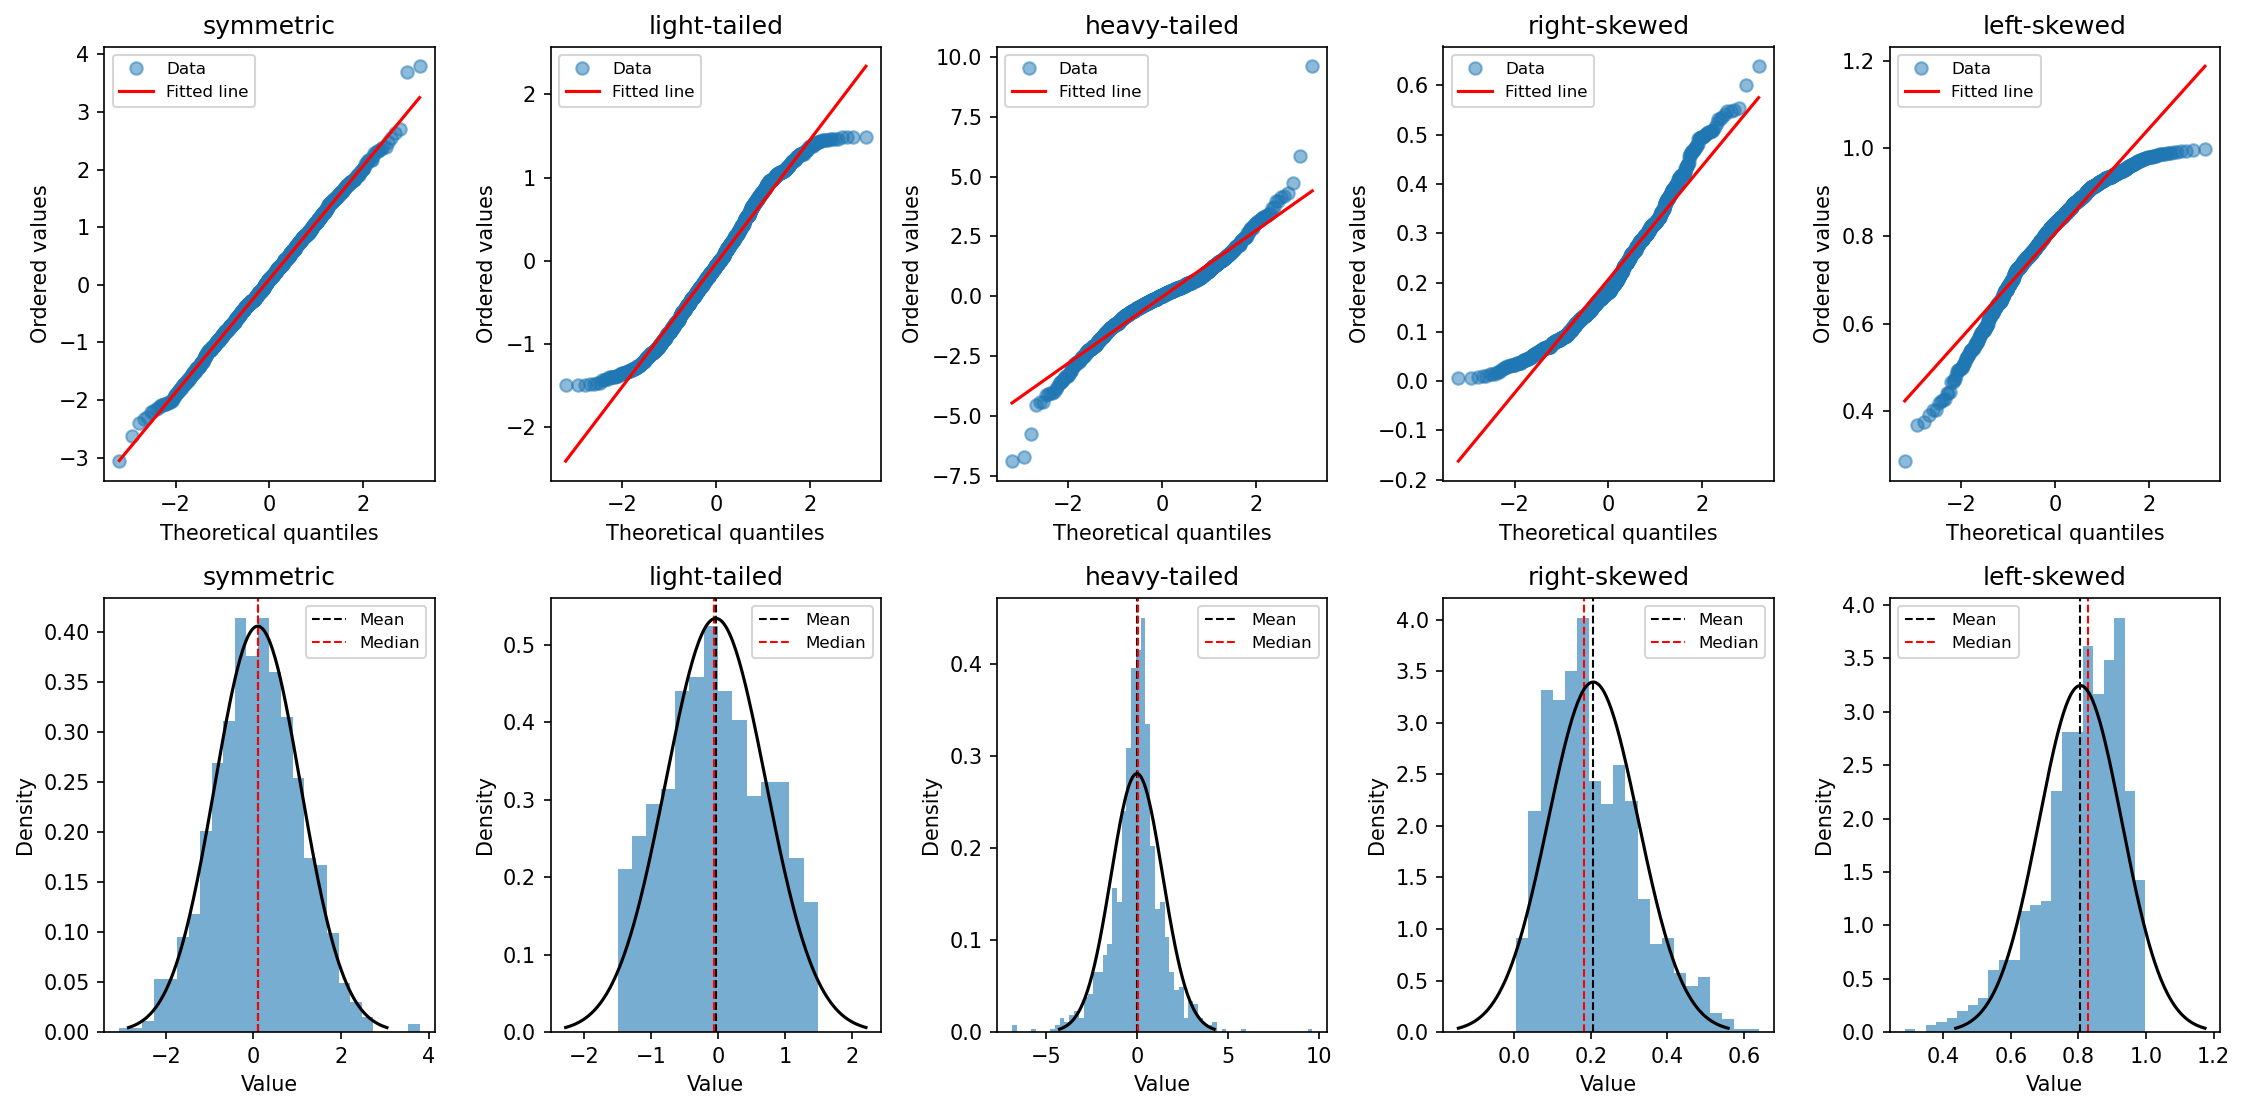

In [12]:
# QQ plot con scipy - distintas distribuciones

N = 1000
dists = {
    'symmetric': stats.norm(),
    'light-tailed': stats.truncnorm(-1.5, 1.5),
    'heavy-tailed': stats.laplace(),
    'right-skewed': stats.beta(2, 8),
    'left-skewed': stats.beta(8, 2)
}

# 2 filas (QQ + hist) x 5 columnas (una por distribucion)
fig, axs = plt.subplots(2, len(dists), figsize=(15, 7.5), dpi=150)

for col, (name, dist) in enumerate(dists.items()):
    x = dist.rvs(N)

    # QQ plot contra normal estandar
    (osm, osr), (slope, intercept, r) = stats.probplot(x, dist='norm')
    axs[0, col].plot(osm, osr, 'o', alpha=0.5, label='Data')
    axs[0, col].plot(osm, slope * osm + intercept, 'r-', label='Fitted line')
    axs[0, col].set_title(name)
    axs[0, col].set_xlabel('Theoretical quantiles')
    axs[0, col].set_ylabel('Ordered values')
    axs[0, col].legend(fontsize=8)

    # Histograma + ajuste normal con media/desviacion de la muestra
    mean = x.mean()
    median = np.median(x)
    axs[1, col].hist(x, density=True, bins='auto', histtype='stepfilled', alpha=0.6)
    xgrid = np.linspace(x.mean() - x.std() * 3, x.mean() + x.std() * 3, 200)
    axs[1, col].axvline(mean, color='k', linestyle='dashed', linewidth=1, label='Mean')
    axs[1, col].axvline(median, color='r', linestyle='dashed', linewidth=1, label='Median')
    axs[1, col].plot(xgrid, stats.norm(loc=x.mean(), scale=x.std()).pdf(xgrid), 'k-')
    axs[1, col].set_title(name)
    axs[1, col].set_xlabel('Value')
    axs[1, col].set_ylabel('Density')
    axs[1, col].legend(fontsize=8)

plt.tight_layout()
fig.savefig('figures/qqplots_different_distributions.pdf', transparent=True, bbox_inches='tight')
plt.show()

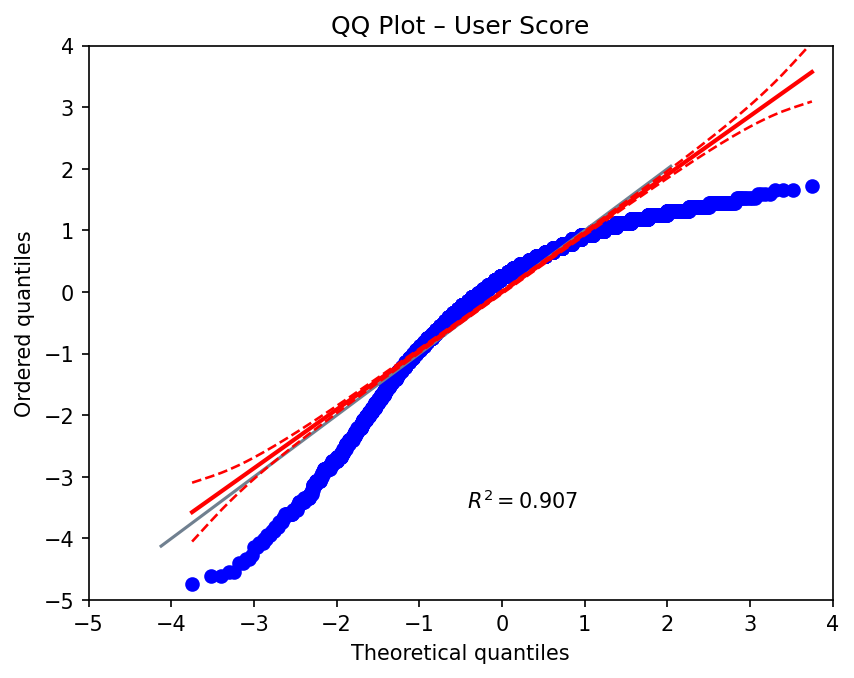

In [158]:

data = vj_df['User_Score'].dropna()

# pingouin.qqplot muestra la banda de confianza automáticamente
fig, ax = plt.subplots(dpi=150)
pg.qqplot(data, dist='norm', ax = ax, square=False, )
ax.set_title('QQ Plot – User Score')
ax.set_xlim(-5,4)
ax.set_ylim(-5,4)
fig.savefig('figures/qqplot_user_score.pdf', transparent=True)
plt.show()

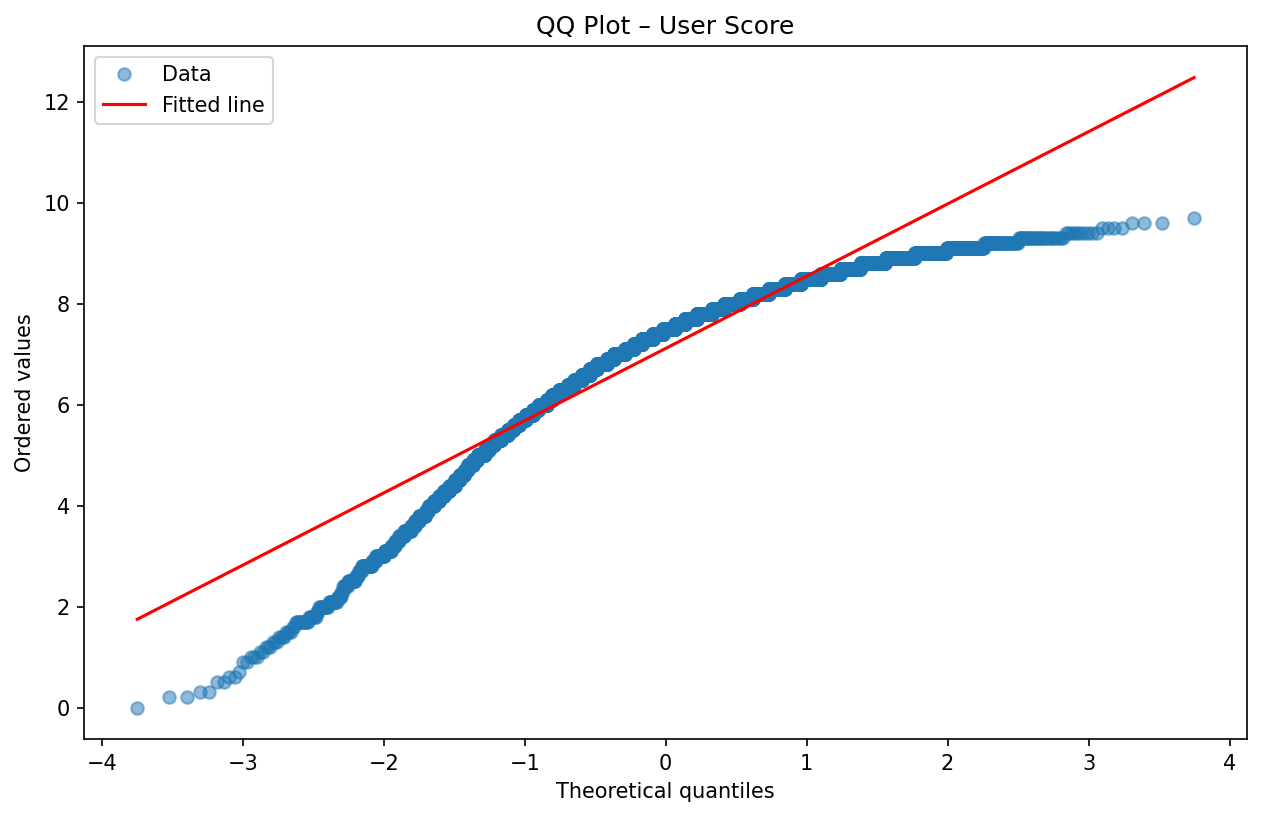

In [150]:
# se puede hacer lo mismo con scipy, al obtener los quantiles teóricos y ordenados crudos
(osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
ax.plot(osm, osr, 'o', alpha=0.5, label='Data')
ax.plot(osm, slope * osm + intercept, 'r-', label='Fitted line')
ax.set_title('QQ Plot – User Score')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Ordered values')
ax.legend()

## P3

In [161]:
print(vj_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17416 entries, 0 to 17415
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             17416 non-null  object 
 1   Platform         17416 non-null  object 
 2   Year_of_Release  17408 non-null  float64
 3   Genre            17416 non-null  object 
 4   Publisher        17415 non-null  object 
 5   NA_Sales         17416 non-null  float64
 6   EU_Sales         17416 non-null  float64
 7   JP_Sales         17416 non-null  float64
 8   Other_Sales      17416 non-null  float64
 9   Global_Sales     17416 non-null  float64
 10  Critic_Score     8336 non-null   float64
 11  Critic_Count     8336 non-null   float64
 12  User_Score       7798 non-null   float64
 13  User_Count       7798 non-null   float64
 14  Rating           10252 non-null  object 
dtypes: float64(10), object(5)
memory usage: 2.0+ MB
None


In [21]:
# P3
categorias = vj_df['Publisher'].unique()
categorias


array(['Nintendo', 'Microsoft Game Studios', 'Take-Two Interactive',
       'Sony Computer Entertainment', 'Activision', 'Ubisoft',
       'Electronic Arts', 'Bethesda Softworks', 'Sega', 'SquareSoft',
       'Atari', '505 Games', 'Capcom', 'GT Interactive',
       'Konami Digital Entertainment', 'Square Enix',
       'Sony Computer Entertainment Europe', 'Virgin Interactive',
       'LucasArts', 'Warner Bros. Interactive Entertainment',
       'Universal Interactive', 'Eidos Interactive', 'RedOctane',
       'Vivendi Games', 'Enix Corporation', 'Namco Bandai Games',
       'Palcom', 'Hasbro Interactive', 'THQ', 'Fox Interactive',
       'Acclaim Entertainment', 'MTV Games', 'Disney Interactive Studios',
       'Codemasters', 'Majesco Entertainment', 'Red Or', 'Level 5',
       'Arena Entertainment', 'Midway Games', 'JVC', 'Deep Silver',
       'NCSoft', '989 Studios', 'UEP Systems', 'Parker Bros.', 'Maxis',
       'Imagic', 'Tecmo Koei', 'ASCII Entertainment', 'Valve Software',
      

In [165]:
vj_df['Publisher'].value_counts()

Publisher
Electronic Arts                 1380
Activision                      1005
Namco Bandai Games               972
Ubisoft                          970
Konami Digital Entertainment     865
                                ... 
Vap                                1
TYO                                1
Navarre Corp                       1
Pow                                1
Team Meat                          1
Name: count, Length: 627, dtype: int64

## P4

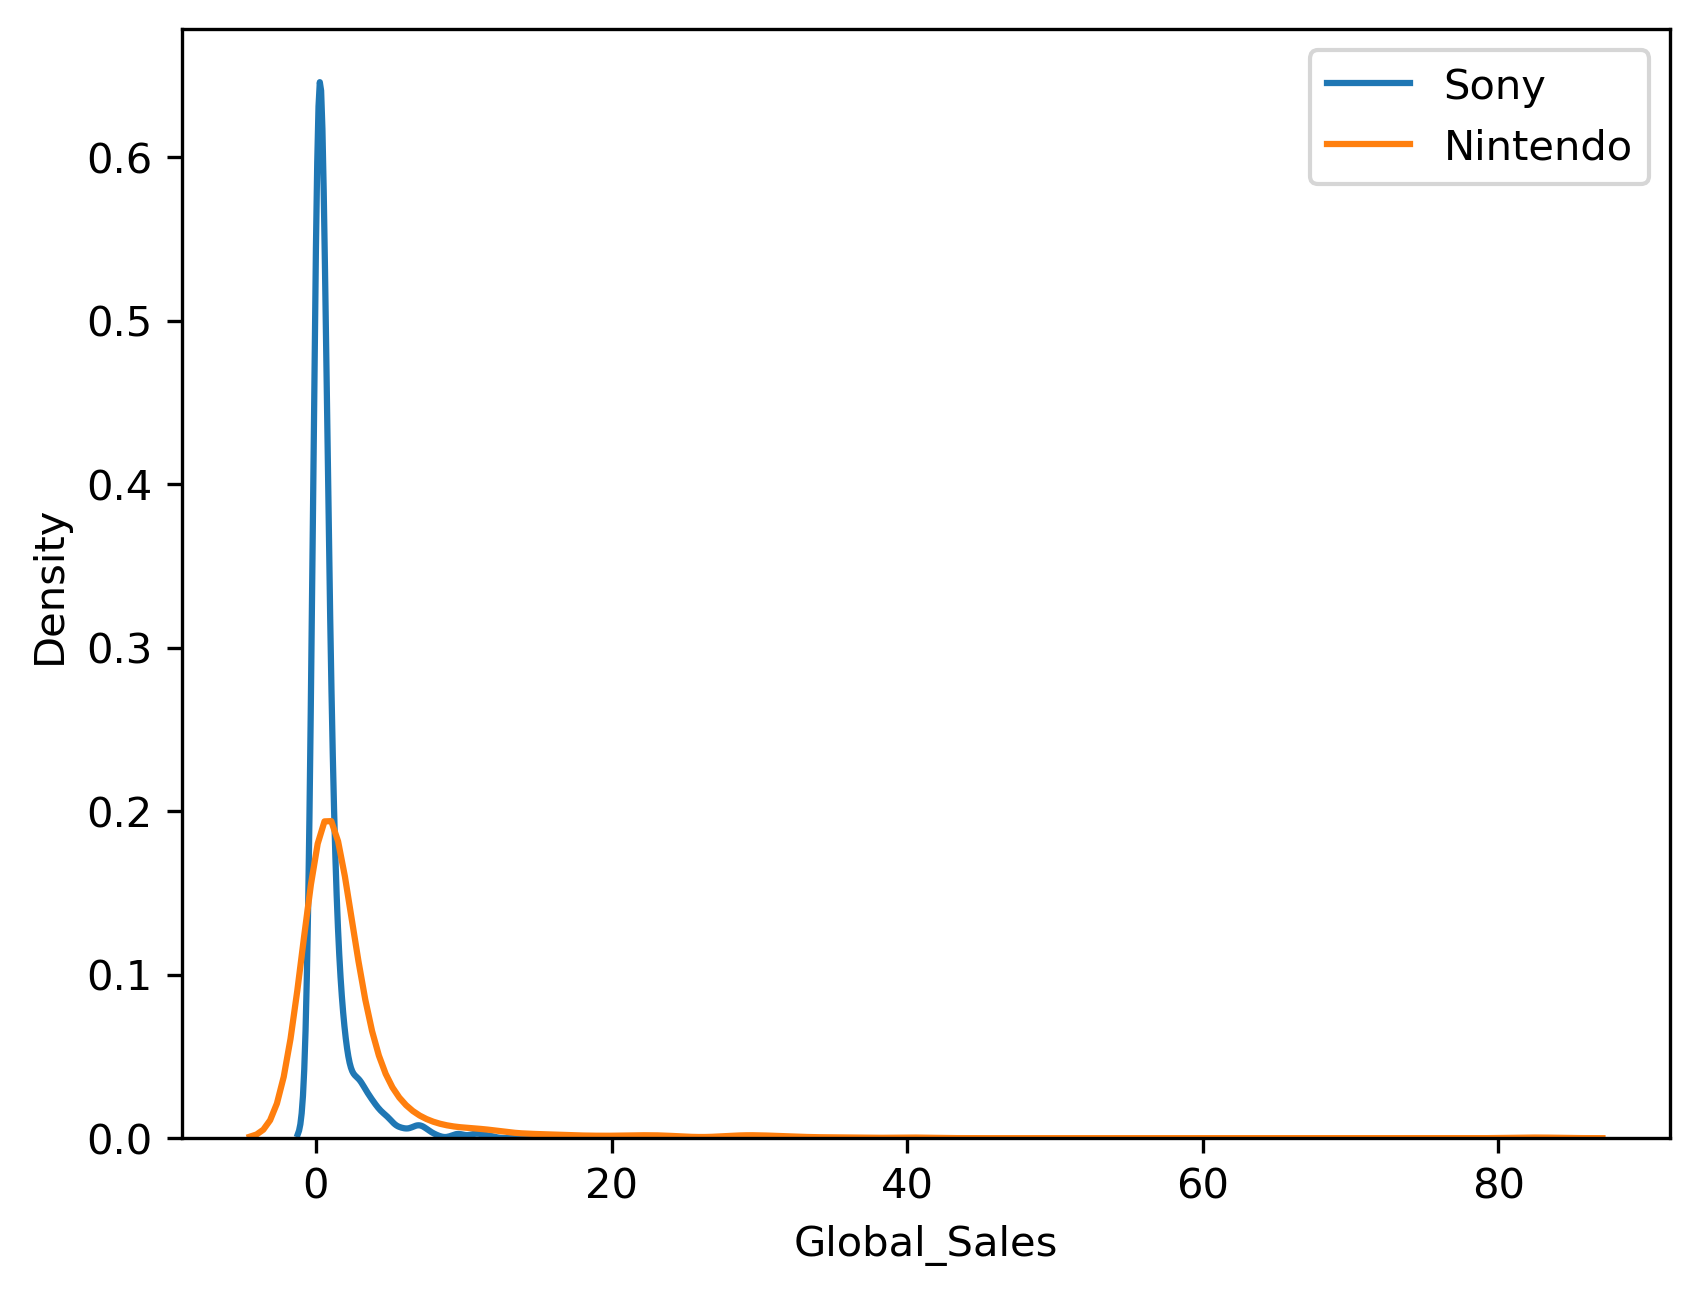

In [168]:
# P4

nintendo = []
sony = []
pub_nonnan = vj_df['Publisher'].dropna()
for i in pub_nonnan.index:
    publisher = pub_nonnan.loc[i]
    if 'nintendo' in publisher.lower():
        nintendo.append(publisher)
    elif 'sony' in publisher.lower():
        sony.append(publisher)
nintendo = np.unique(nintendo)
sony = np.unique(sony)
ventas_sony = vj_df[vj_df['Publisher'].isin(sony)]['Global_Sales']
ventas_nintendo = vj_df[vj_df['Publisher'].isin(nintendo)]['Global_Sales']
fig, ax = plt.subplots(dpi = 300)
sns.kdeplot(ventas_sony, label = 'Sony')
sns.kdeplot(ventas_nintendo, label = 'Nintendo')
plt.legend()
fig.savefig('figures/ventas_sony_nintendo.pdf', transparent=True)
plt.show()

## P5

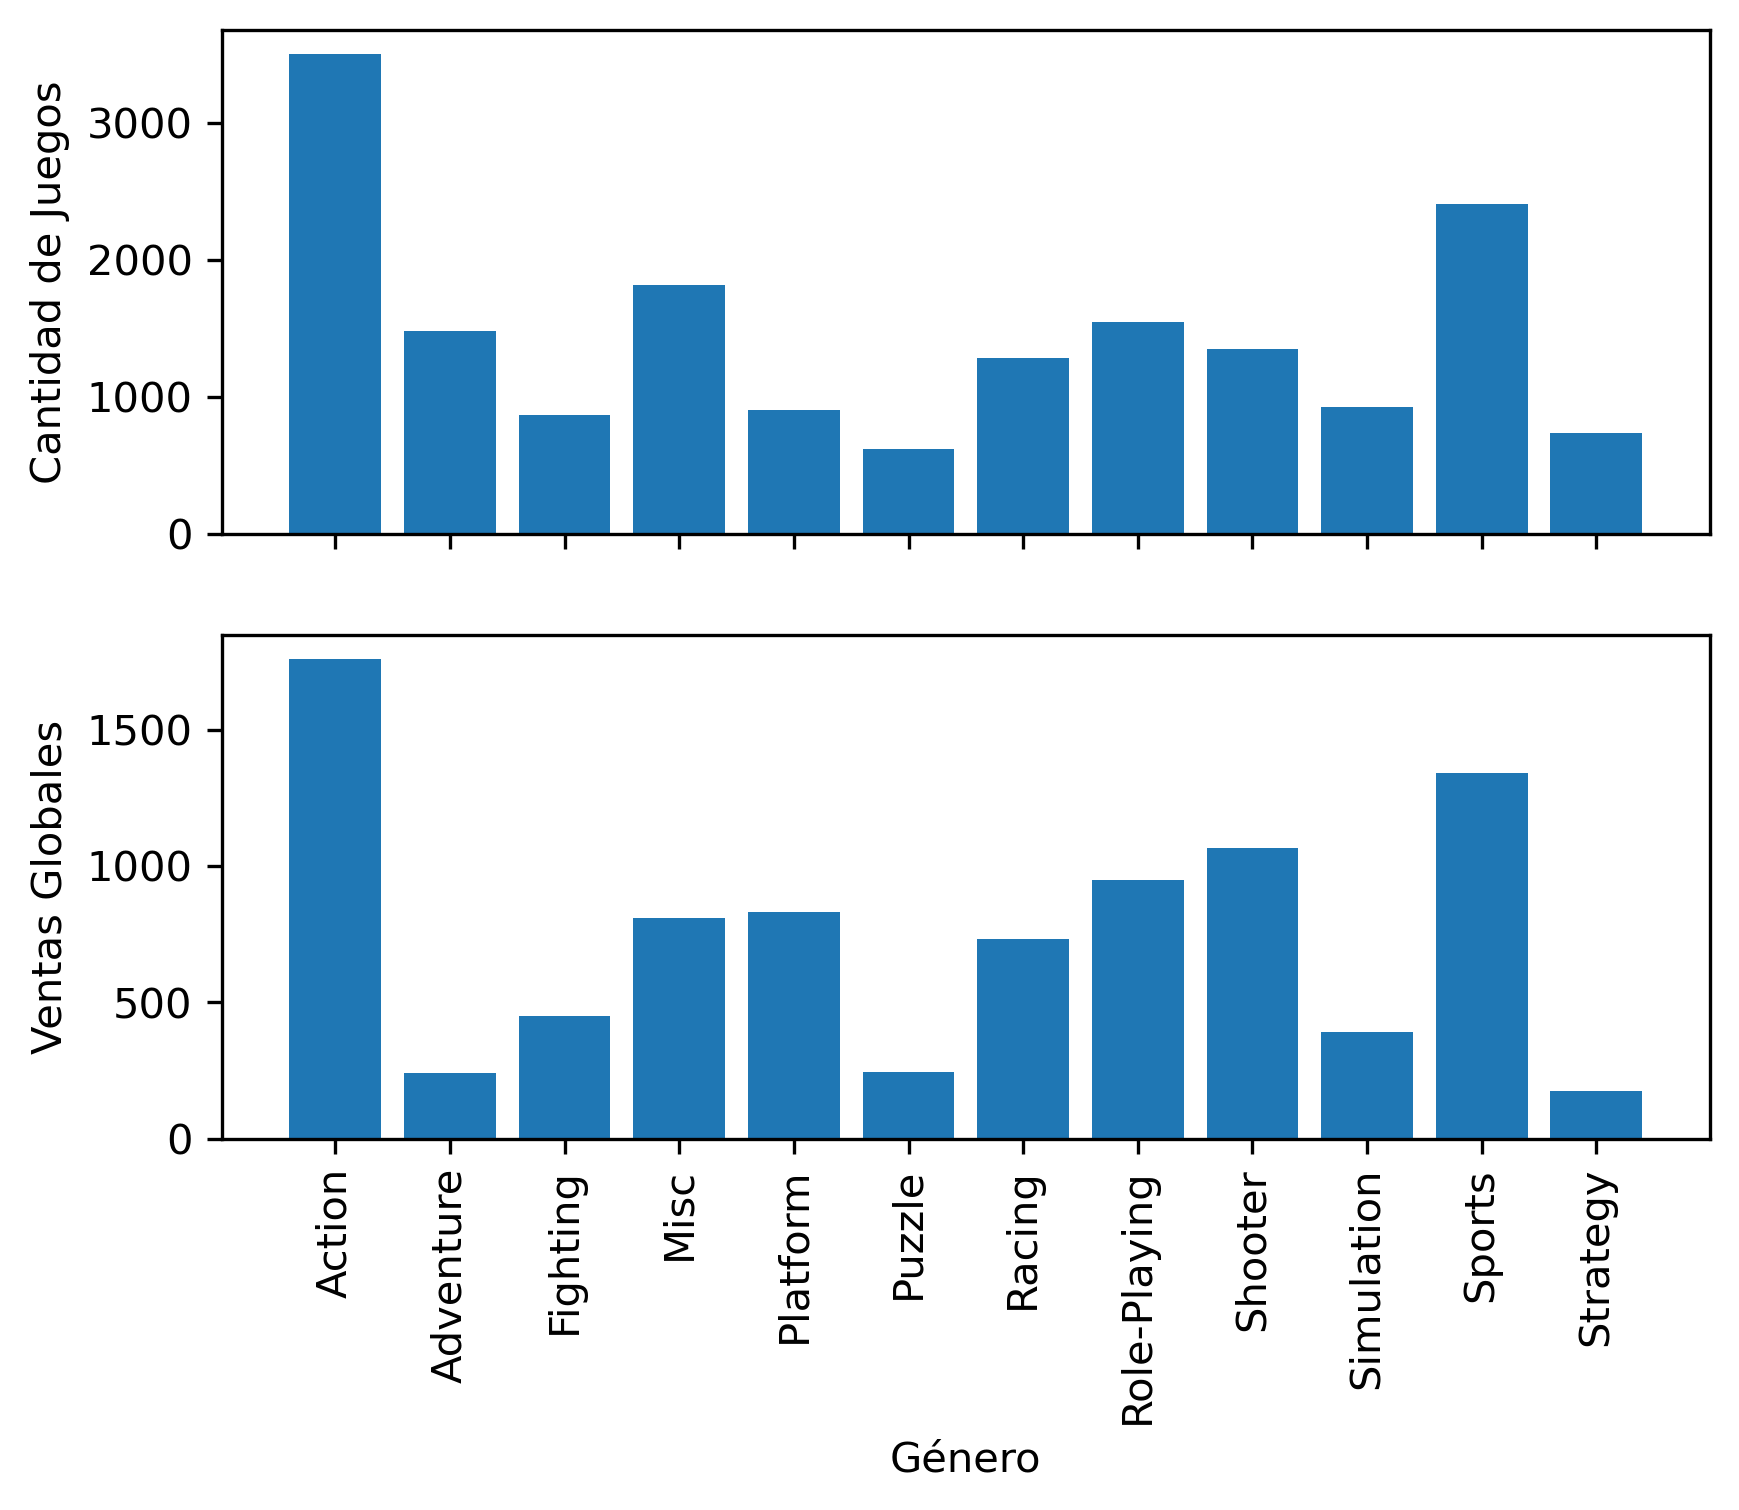

In [169]:
#P5
game_per_genre = vj_df.groupby('Genre').count()
quantity_gpg = game_per_genre['Name'] # sabemos que son unicos
sales_gpg = vj_df.groupby('Genre').sum()['Global_Sales']
fig, ax = plt.subplots(2,1,dpi = 300, sharex = True)
ax[0].bar(quantity_gpg.index, quantity_gpg)
ax[0].set_ylabel('Cantidad de Juegos')
ax[1].bar(sales_gpg.index, sales_gpg)
ax[1].set_ylabel('Ventas Globales')
plt.xticks(rotation = 90)
plt.xlabel('Género')
fig.savefig('figures/quantity_sales_by_genre.pdf', transparent=True, bbox_inches='tight')
plt.show()

In [25]:
game_per_genre

,Name,Platform,Year_of_Release,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
Genre,,,,,,,,,,,,,,
Action,3503,3503,3500,3502,3503,3503,3503,3503,3503,1933,1933,1878,1878,2250
Adventure,1478,1478,1478,1478,1478,1478,1478,1478,1478,342,342,314,314,472
Fighting,864,864,864,864,864,864,864,864,864,418,418,409,409,448
Misc,1813,1813,1812,1813,1813,1813,1813,1813,1813,528,528,446,446,902
Platform,900,900,900,900,900,900,900,900,900,501,501,435,435,581
Puzzle,615,615,615,615,615,615,615,615,615,232,232,135,135,364
Racing,1282,1282,1281,1282,1282,1282,1282,1282,1282,756,756,653,653,898
Role-Playing,1545,1545,1545,1545,1545,1545,1545,1545,1545,759,759,766,766,796
Shooter,1349,1349,1348,1349,1349,1349,1349,1349,1349,963,963,945,945,1042


In [26]:
sales_gpg

Genre
Action          1761.97
Adventure        241.55
Fighting         449.17
Misc             808.80
Platform         831.74
Puzzle           243.76
Racing           731.67
Role-Playing     949.31
Shooter         1067.30
Simulation       392.84
Sports          1341.00
Strategy         175.72
Name: Global_Sales, dtype: float64

# Oscar

## P1

In [27]:
# P1
link = 'https://github.com/SysBioengLab/IIQ3402-Statistical-Design/blob/main/SetDeDatos/oscars_df.csv?raw=true'
oscar_df = pd.read_csv(link)
if 'Unnamed: 0' in oscar_df.columns:
    oscar_df = oscar_df.drop('Unnamed: 0', axis=1)
# importante: IMDB votes son números tomados como string por pandas
oscar_df.head(5)

,Film,Oscar Year,Film Studio/Producer(s),Award,Year of Release,Movie Time,Movie Genre,IMDB Rating,IMDB Votes,Movie Info,...,Tomatometer Status,Tomatometer Rating,Tomatometer Count,Audience Status,Audience Rating,Audience Count,Tomatometer Top Critics Count,Tomatometer Fresh Critics Count,Tomatometer Rotten Critics Count,Film ID
0,Wings,1927/28,Famous Players-Lasky,Winner,1927,144,"Drama,Romance,War",7.5,"12,221","With World War I afoot, David Armstrong (Richa...",...,Certified-Fresh,93.0,46.0,Upright,78.0,3530.0,9.0,43.0,3.0,2becf7d5-a3de-46ab-ae45-abdd6b588067
1,7th Heaven,1927/28,Fox,Nominee,1927,110,"Drama,Romance",7.7,"3,439",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19ed3295-a878-4fd2-8e60-5cd7b5f93dad
2,The Racket,1927/28,The Caddo Company,Nominee,1928,84,"Crime,Drama,Film-Noir",6.7,"1,257",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3111c2d8-0908-4093-8ff3-99c89f2f2f08
3,The Broadway Melody,1928/29,Metro-Goldwyn-Mayer,Winner,1929,100,"Drama,Musical,Romance",5.7,"6,890","Vaudeville sisters ""Hank"" (Bessie Love) and Qu...",...,Rotten,33.0,24.0,Spilled,21.0,1813.0,7.0,8.0,16.0,de063f3f-2d35-4e1c-8636-6eb4c16bd236
4,Alibi,1928/29,Feature Productions,Nominee,1929,91,"Action,Crime,Romance",5.8,765,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,609887c2-877c-43a4-b88c-e40e31096a98


In [28]:
oscar_df['IMDB Votes'] = oscar_df['IMDB Votes'].str.replace(',', '').astype(int)

In [29]:
descrip_group = oscar_df.groupby('Award').describe()
descrip_group

Year of Release                                                  \
                  count         mean        std     min     25%     50%   
Award                                                                     
Nominee           478.0  1973.361925  29.843420  1927.0  1943.0  1972.0   
Winner             93.0  1973.333333  26.587564  1927.0  1951.0  1973.0   

                        Movie Time              ...  \
            75%     max      count        mean  ...   
Award                                           ...   
Nominee  2002.0  2021.0      478.0  122.228033  ...   
Winner   1996.0  2019.0       93.0  138.602151  ...   

        Tomatometer Fresh Critics Count         \
                                    75%    max   
Award                                            
Nominee                          173.00  495.0   
Winner                           100.75  414.0   

        Tomatometer Rotten Critics Count                                   \
                                   count       mean        std  min   25%   
Award                                                                       
Nominee                            357.0  12.319328  20.356072  0.0  2.00   
Winner                              82.0  12.085366  13.968396  1.0  3.25   

                           
         50%   75%    max  
Award                      
Nominee  4.0  15.0  182.0  
Winner   7.0  15.0   80.0  

[2 rows x 88 columns]

## P2

In [170]:
numeric_oscar

,Year of Release,Movie Time,IMDB Rating,IMDB Votes,Tomatometer Rating,Tomatometer Count,Audience Rating,Audience Count,Tomatometer Top Critics Count,Tomatometer Fresh Critics Count,Tomatometer Rotten Critics Count
0,1927,144,7.5,12221,93.0,46.0,78.0,3530.0,9.0,43.0,3.0
1,1927,110,7.7,3439,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1928,84,6.7,1257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1929,100,5.7,6890,33.0,24.0,21.0,1813.0,7.0,8.0,16.0
4,1929,91,5.8,765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
566,2020,131,6.9,65380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
567,2020,115,7.5,57976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
568,2020,113,7.5,122269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
569,2019,120,7.8,102807,NaN,NaN,NaN,NaN,NaN,NaN,NaN


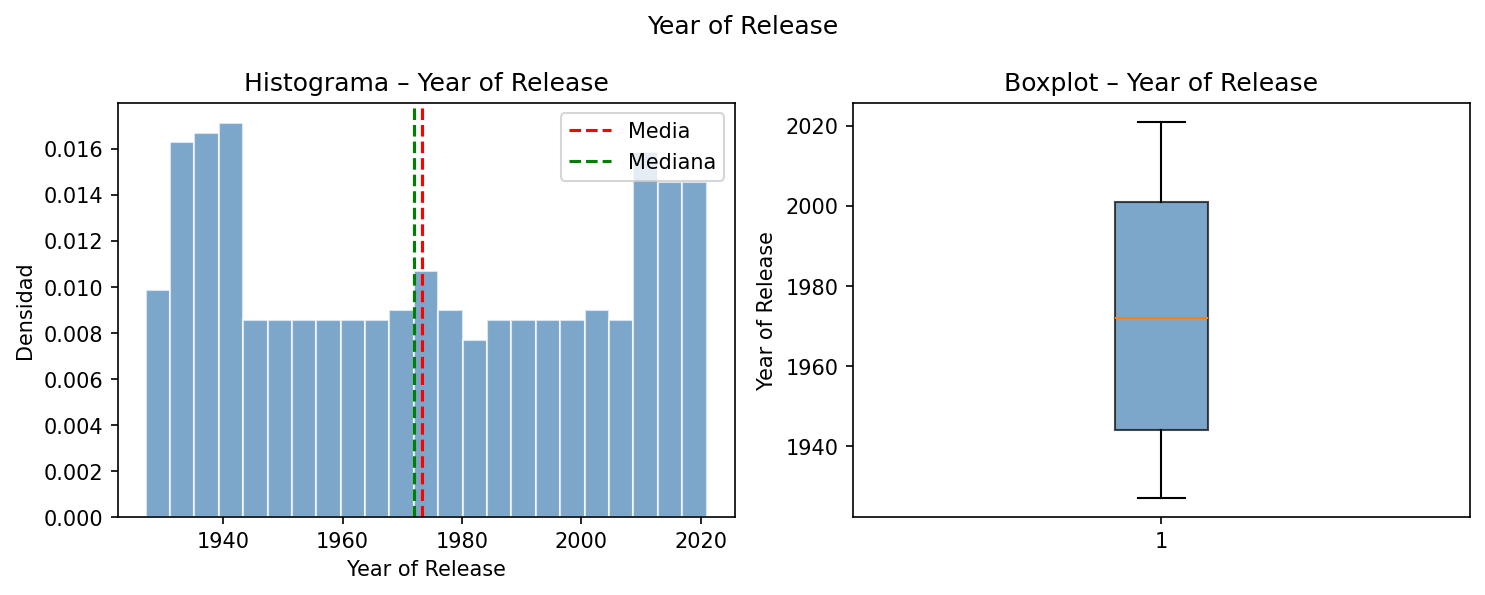

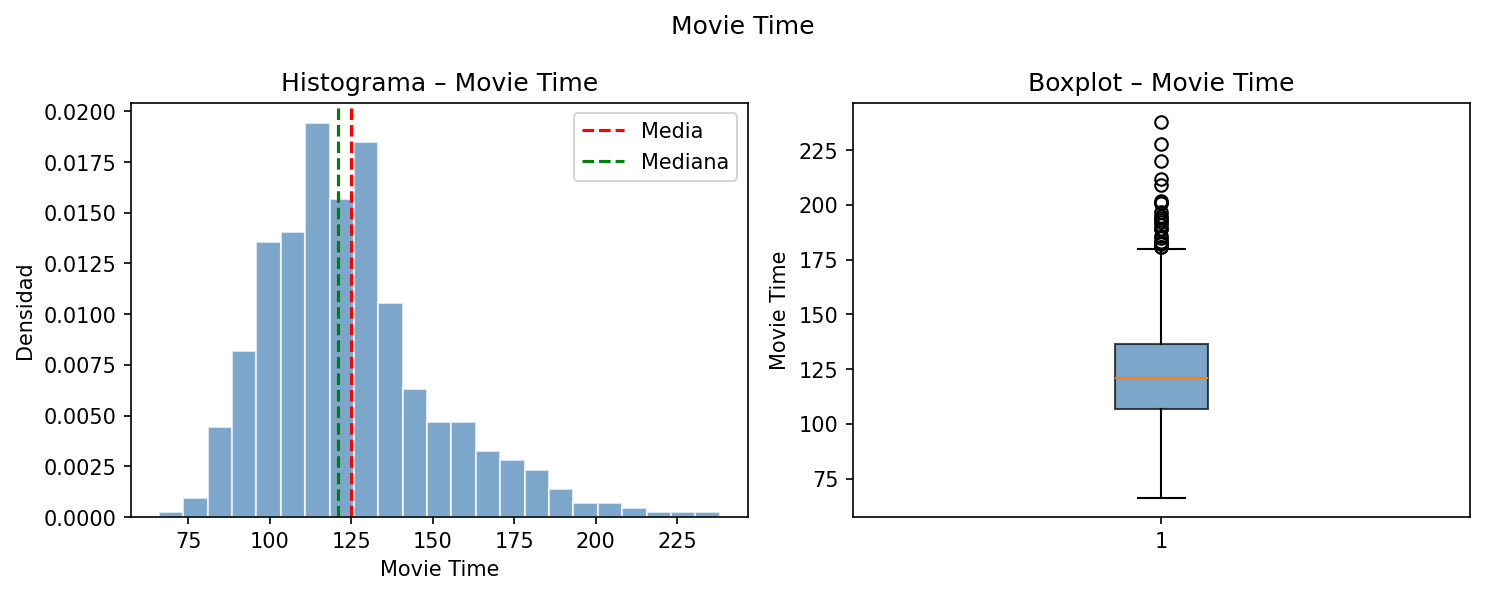

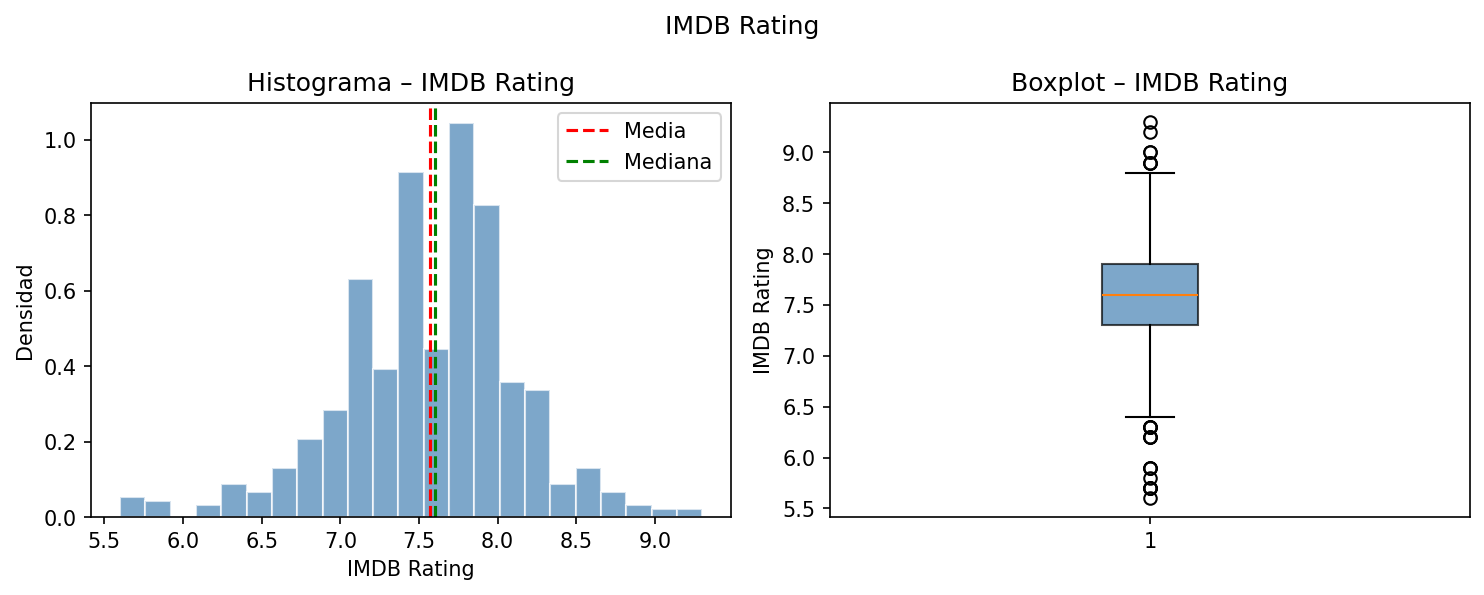

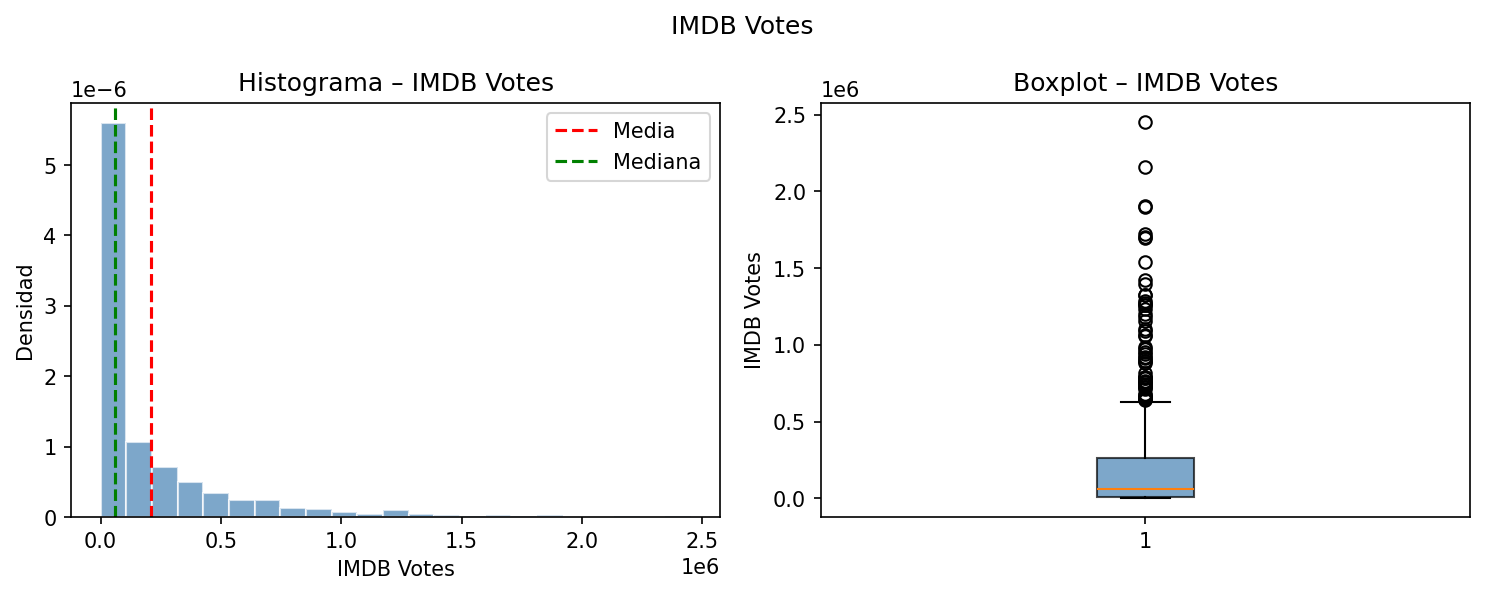

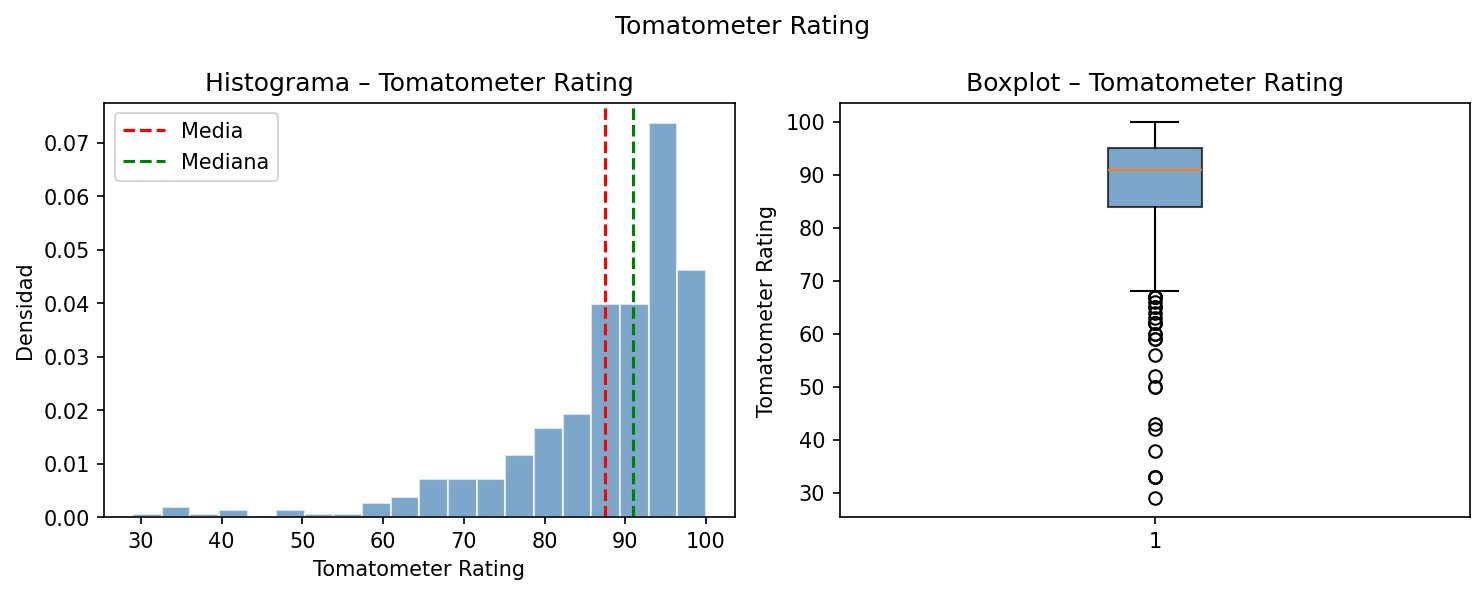

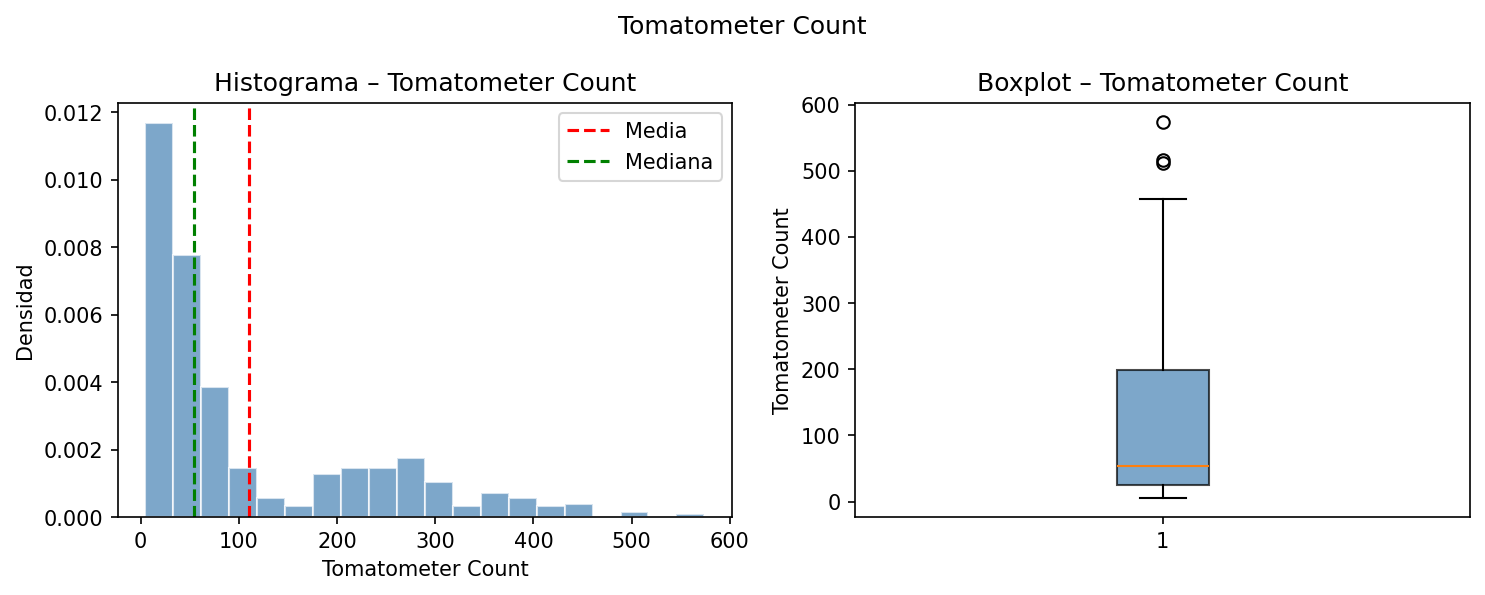

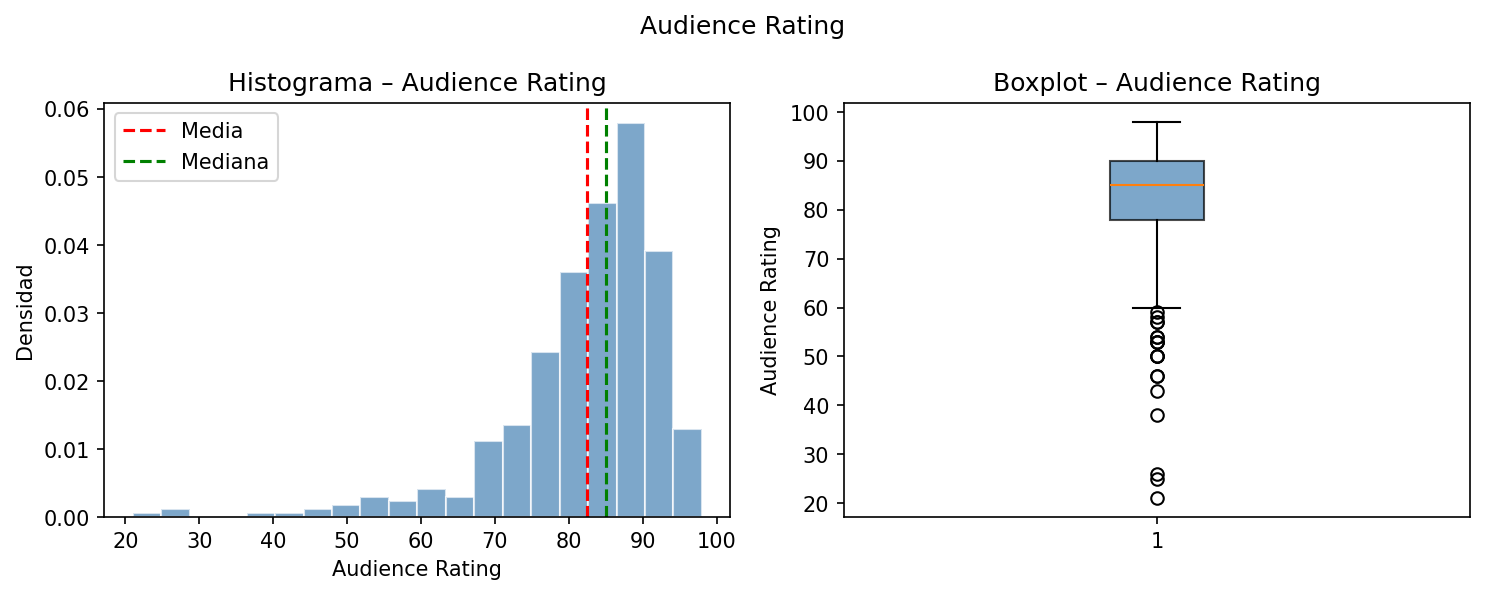

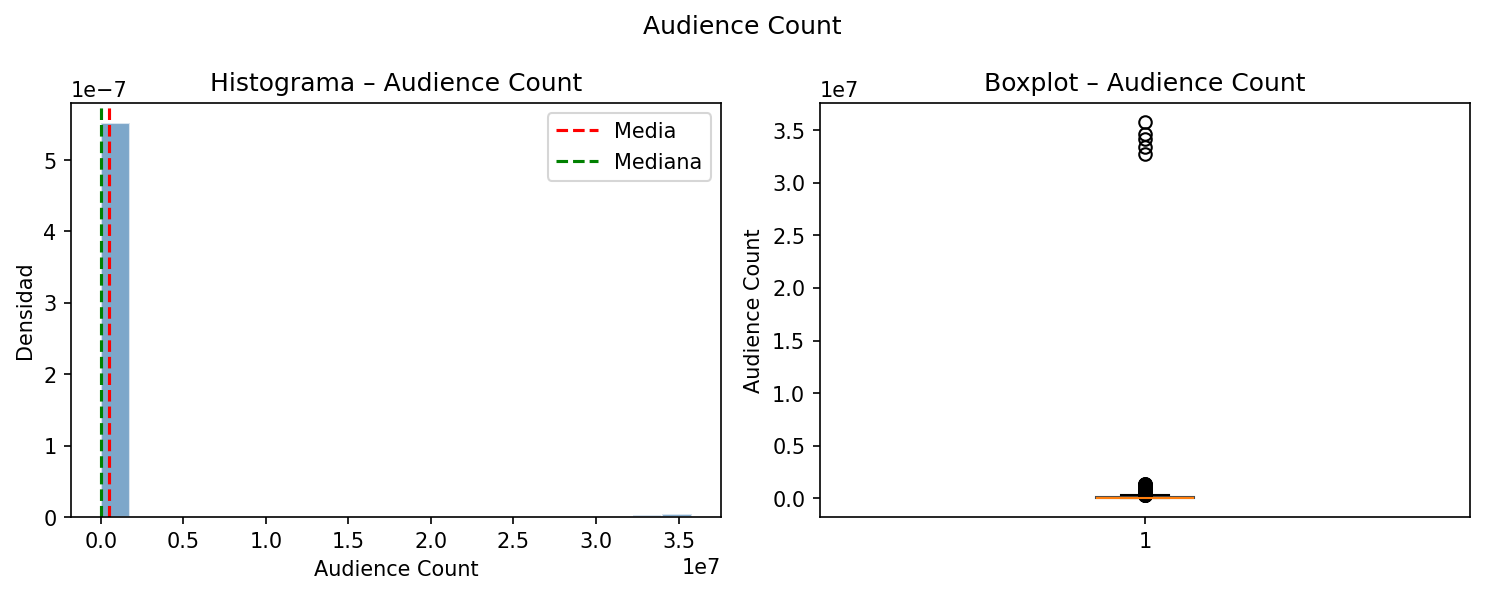

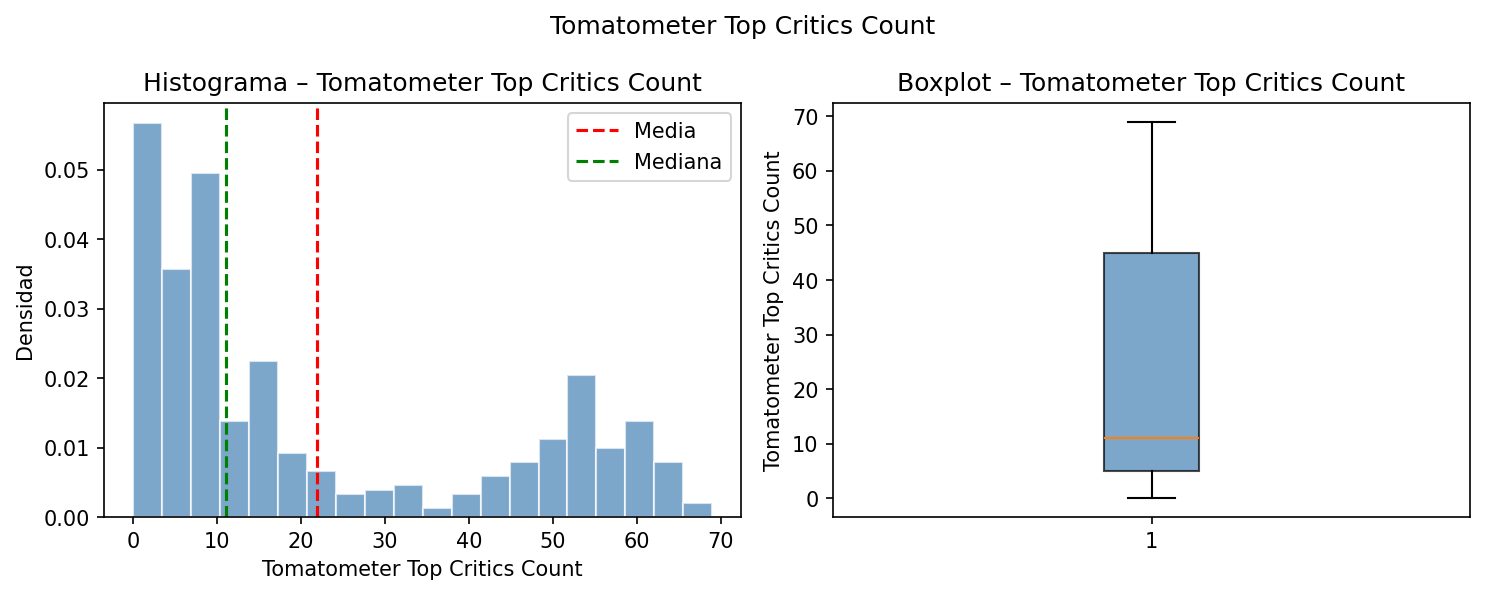

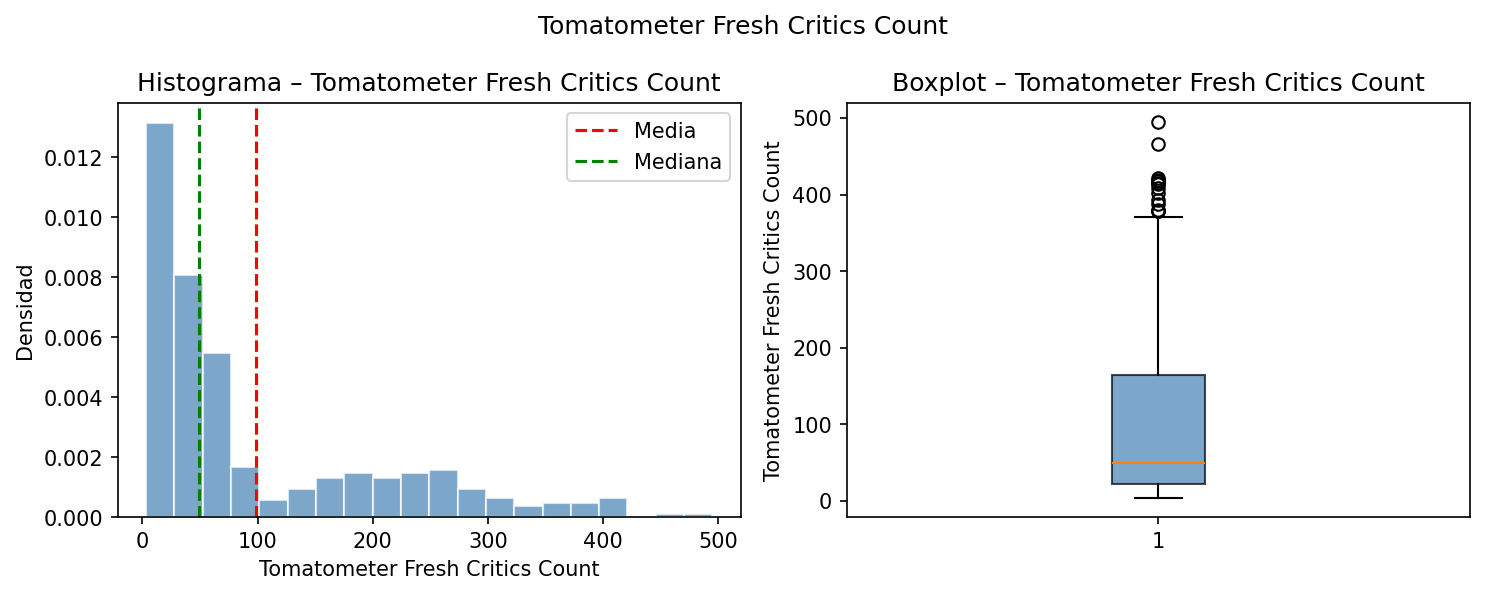

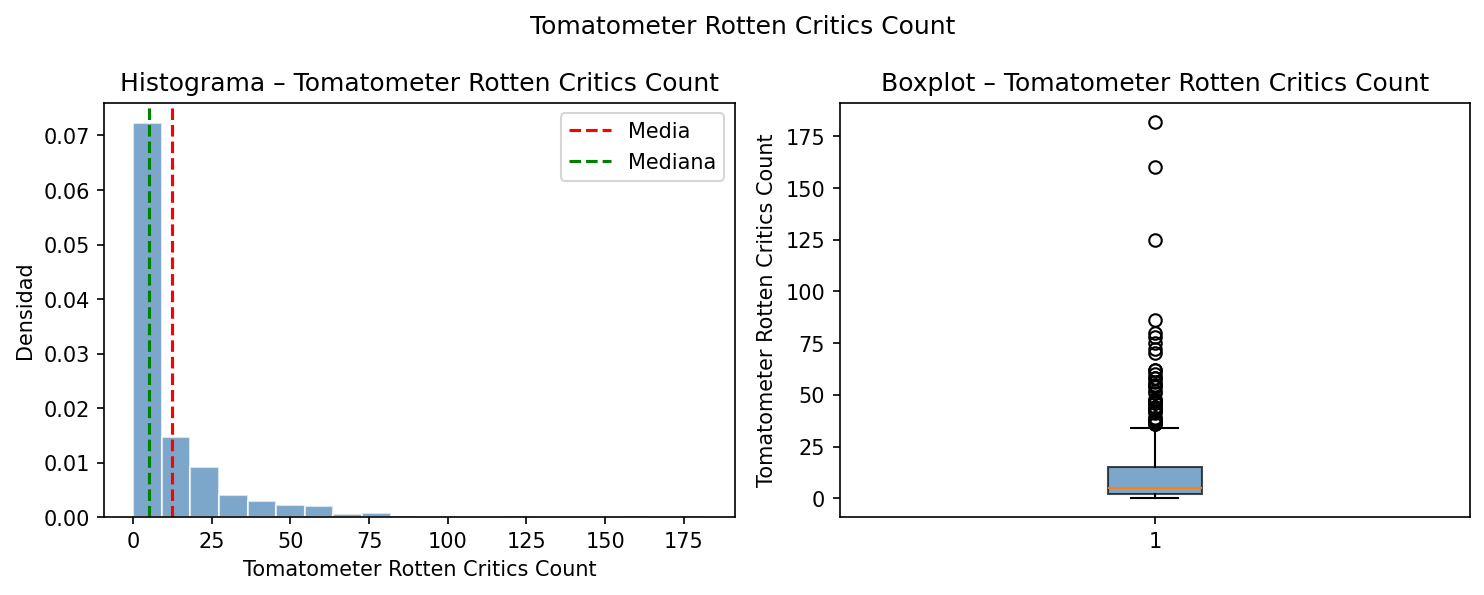

In [30]:
# P2 - Histograma + Boxplot para cada variable numérica
numeric_oscar = oscar_df.select_dtypes(include=[np.number])

for column in numeric_oscar.columns:
    data = oscar_df[column].dropna()
    n_bins = int(np.sqrt(len(data)))

    fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

    ax[0].hist(data, bins=n_bins, alpha=0.7, color='steelblue', density=True, edgecolor='white')
    ax[0].axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.5, label='Media')
    ax[0].axvline(data.median(), color='green', linestyle='--', linewidth=1.5, label='Mediana')
    ax[0].set_xlabel(column)
    ax[0].set_ylabel('Densidad')
    ax[0].set_title(f'Histograma – {column}')
    ax[0].legend()

    ax[1].boxplot(data, patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax[1].set_ylabel(column)
    ax[1].set_title(f'Boxplot – {column}')

    fig.suptitle(column)
    fig.tight_layout()
    plt.show()

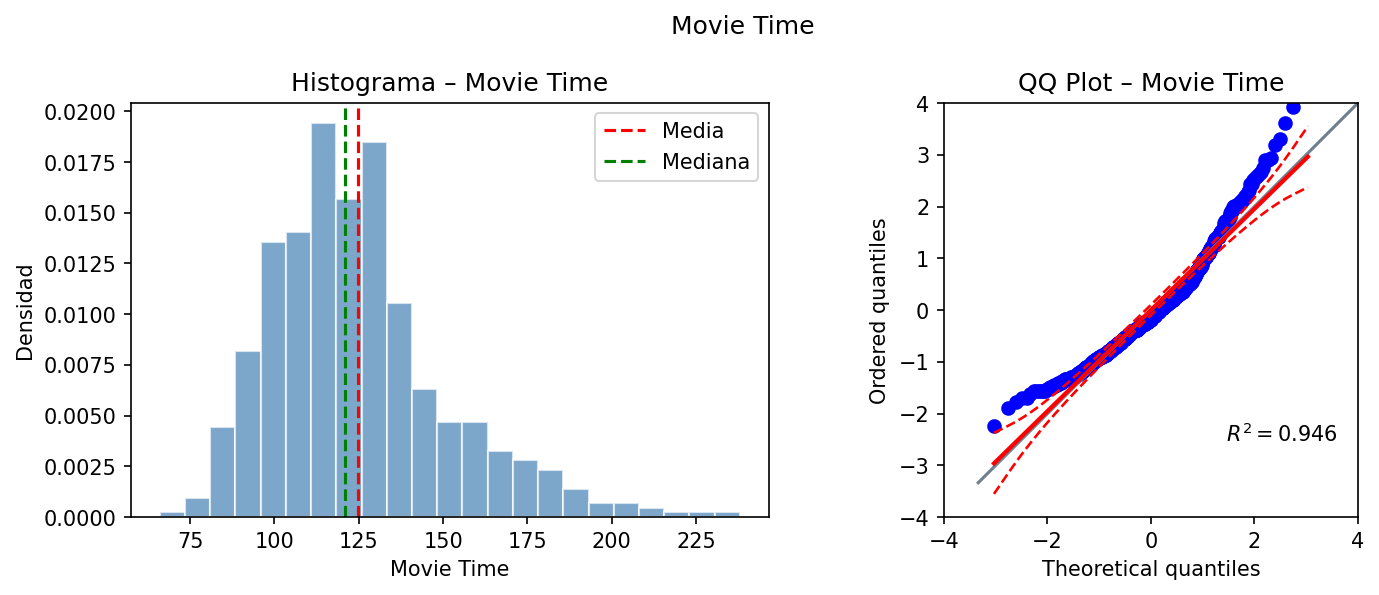

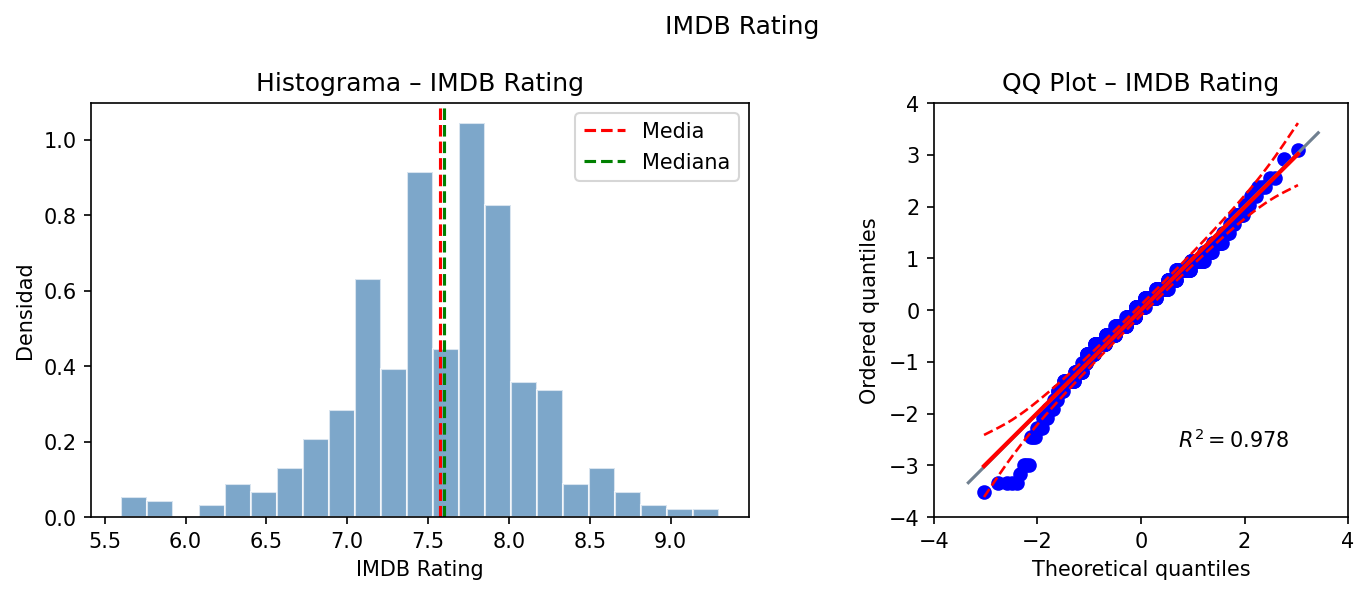

In [ ]:
# P2 - Histograma + QQ Plot para Movie Time e IMDB Rating


for column in ['Movie Time', 'IMDB Rating']:
    data = numeric_oscar[column].dropna()
    n_bins = int(np.sqrt(len(data)))

    fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

    ax[0].hist(data, bins=n_bins, alpha=0.7, color='steelblue', density=True, edgecolor='white')
    ax[0].axvline(data.mean(),   color='red',   linestyle='--', linewidth=1.5, label='Media')
    ax[0].axvline(data.median(), color='green', linestyle='--', linewidth=1.5, label='Mediana')
    ax[0].set_xlabel(column)
    ax[0].set_ylabel('Densidad')
    ax[0].set_title(f'Histograma – {column}')
    ax[0].legend()

    pg.qqplot(data, dist='norm', confidence=0.95, ax=ax[1])
    ax[1].set_title(f'QQ Plot – {column}')
    ax[1].set_xlim(-4, 4)
    ax[1].set_ylim(-4, 4)
    fig.suptitle(column)
    fig.tight_layout()
    plt.show()

## P3

In [32]:
# P3
categoric_oscar = oscar_df.select_dtypes(include=[object])
categoric_oscar.count()

niveles = {}
for column in categoric_oscar.columns:
    niveles[column] = categoric_oscar[column].value_counts()

niveles

{'Film': Film
 Cleopatra                     2
 Little Women                  2
 Heaven Can Wait               2
 Mutiny on the Bounty          2
 Romeo and Juliet              2
                              ..
 The Robe                      1
 Julius Caesar                 1
 From Here to Eternity         1
 The Quiet Man                 1
 The Trial of the Chicago 7    1
 Name: count, Length: 564, dtype: int64,
 'Oscar Year': Oscar Year
 1934       12
 1935       12
 1938       10
 2009       10
 2010       10
            ..
 1966        5
 1965        5
 1964        5
 1963        5
 1927/28     3
 Name: count, Length: 93, dtype: int64,
 'Film Studio/Producer(s)': Film Studio/Producer(s)
 Metro-Goldwyn-Mayer                 40
 Warner Bros.                        20
 20th Century-Fox                    16
 Columbia                            13
 Paramount                           13
                                     ..
 Claude Berri and Timothy Burrill     1
 Jonathan Sanger   

## P4

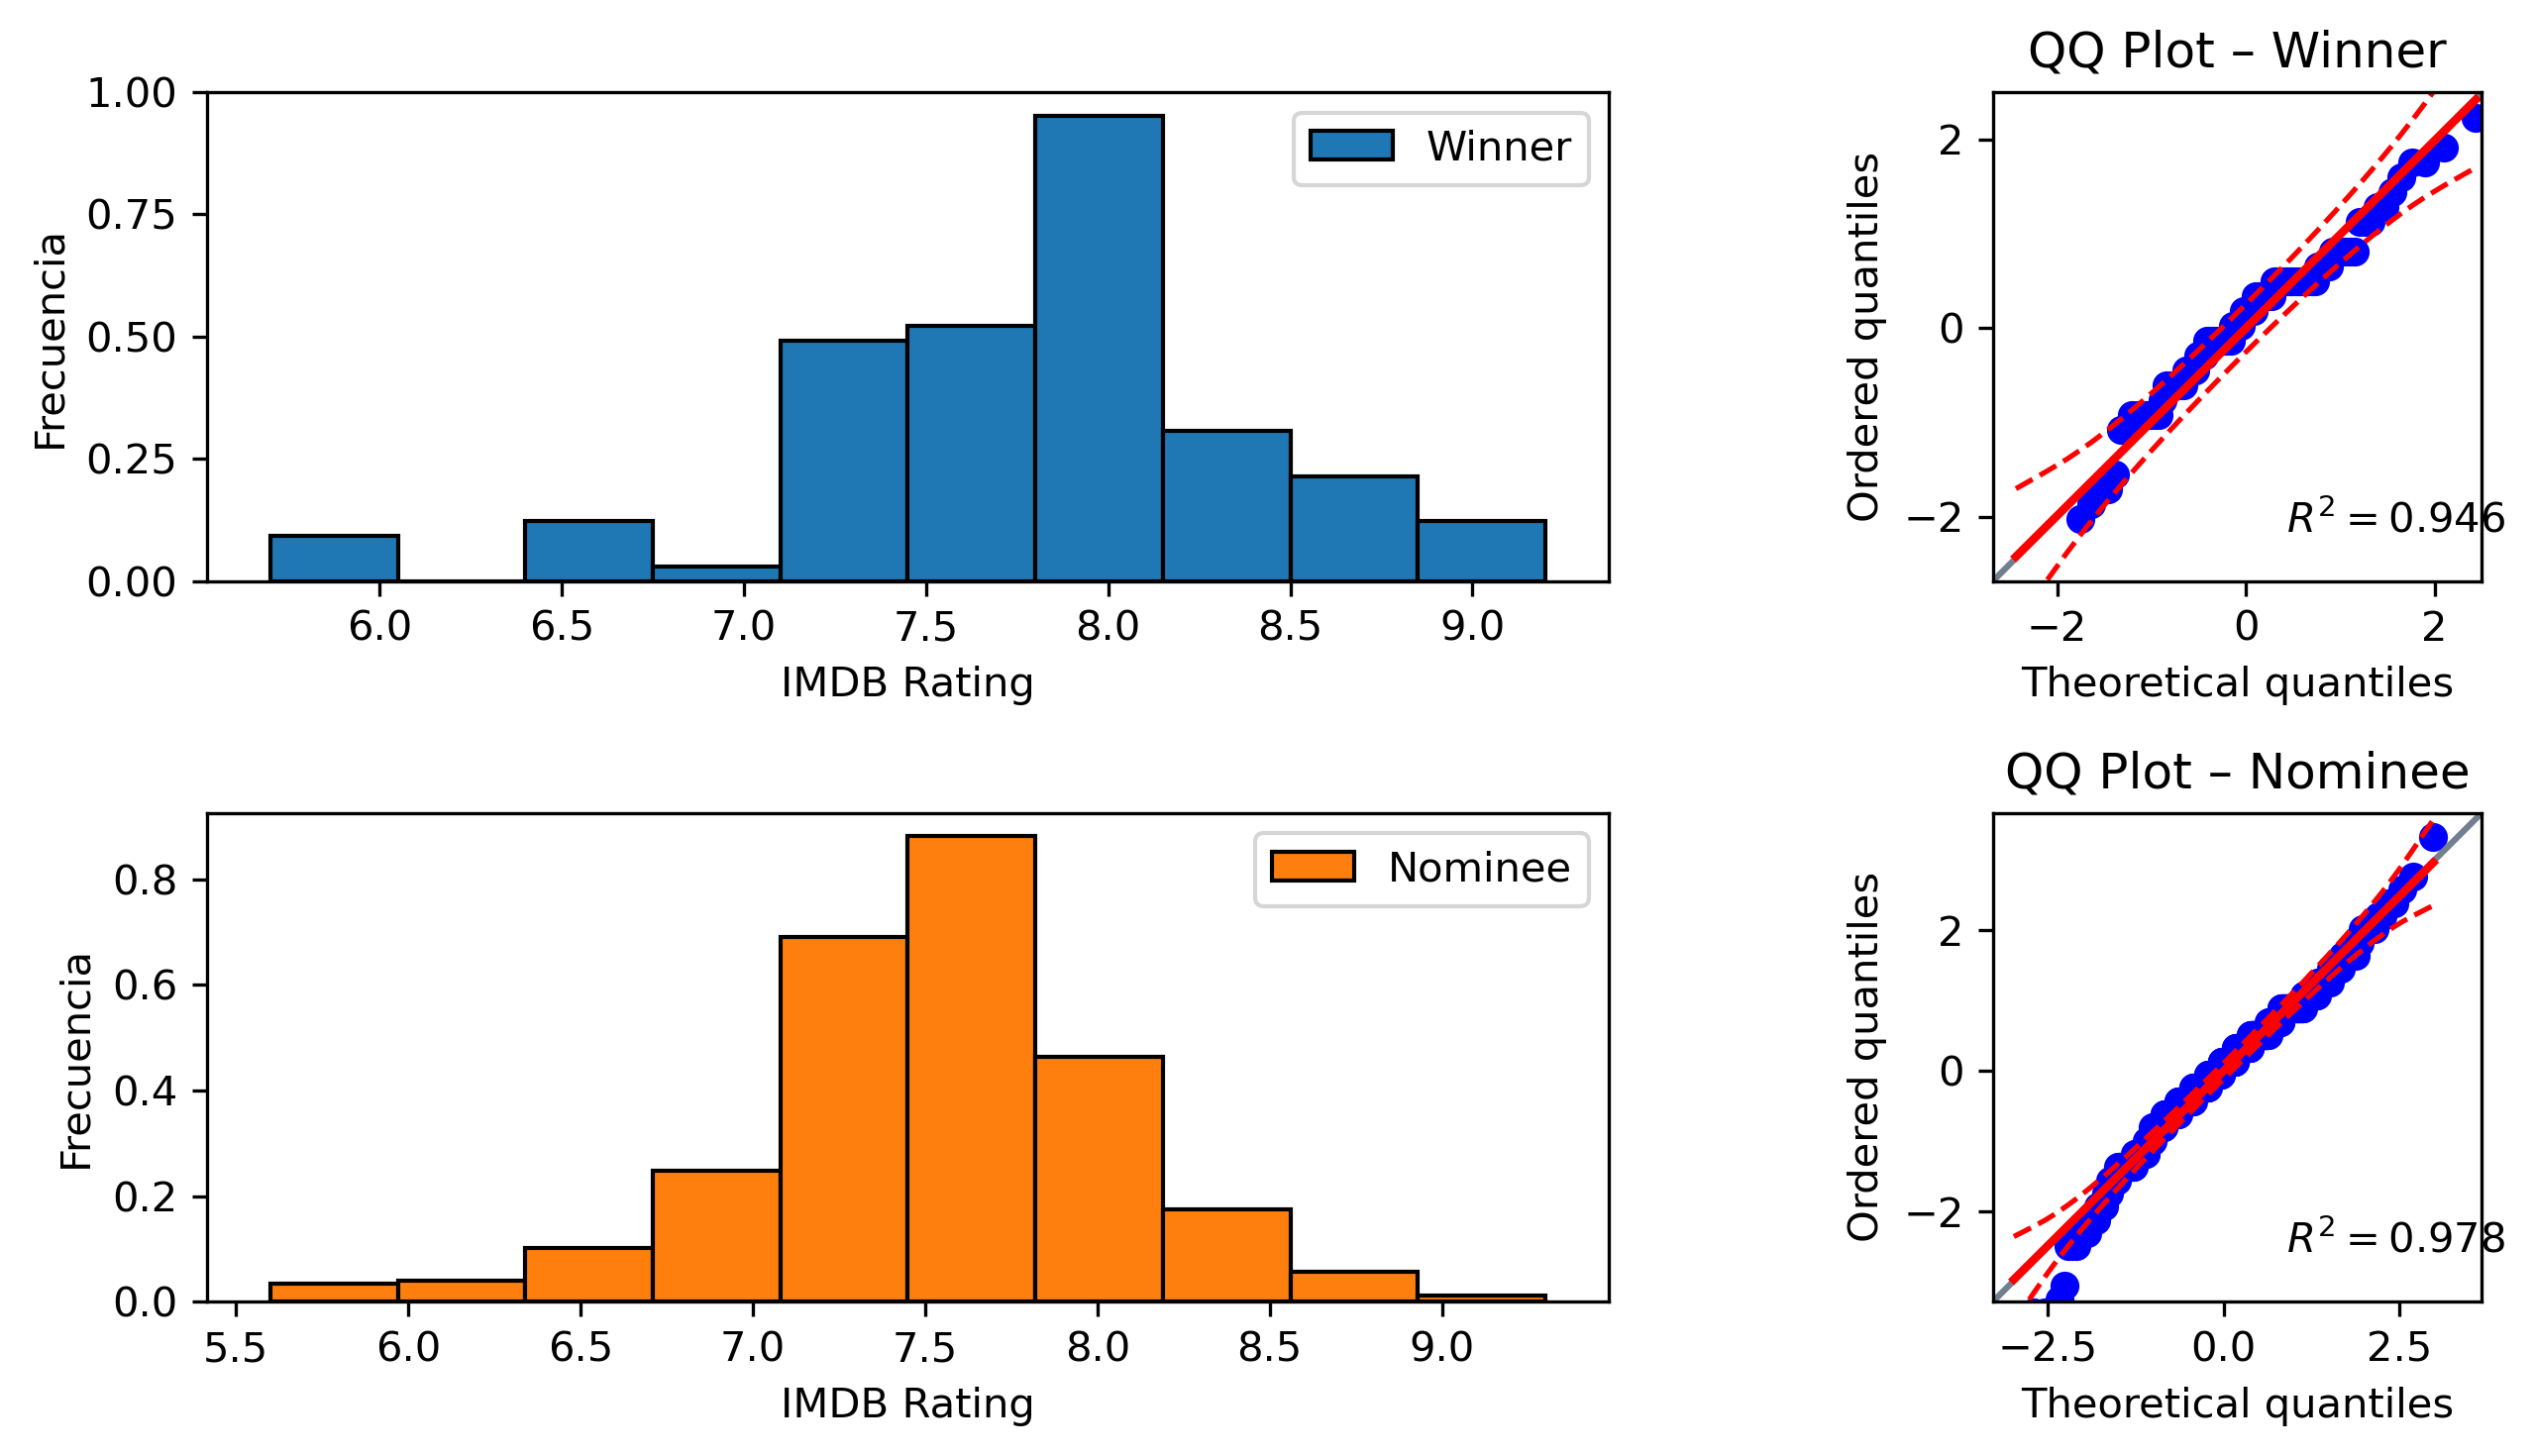

In [ ]:
# P4 - IMDB Rating por Award

rating = oscar_df['Award'].unique()
fig, ax = plt.subplots(2, 2, dpi=300, figsize=(10, 5))
colores = ['tab:blue', 'tab:orange']

for posi, awd in enumerate(rating):
    data = oscar_df[oscar_df['Award'] == awd]['IMDB Rating'].dropna()
    ax[posi, 0].hist(data, density=True, label=awd, facecolor=colores[posi], edgecolor='black')
    ax[posi, 0].set_xlabel('IMDB Rating')
    ax[posi, 0].set_ylabel('Frecuencia')
    ax[posi, 0].legend()
    # pingouin qqplot con ax especificado
    pg.qqplot(data, dist='norm', confidence=0.95, ax=ax[posi, 1])
    ax[posi, 1].set_title(f'QQ Plot - {awd}')

fig.tight_layout()
plt.show()

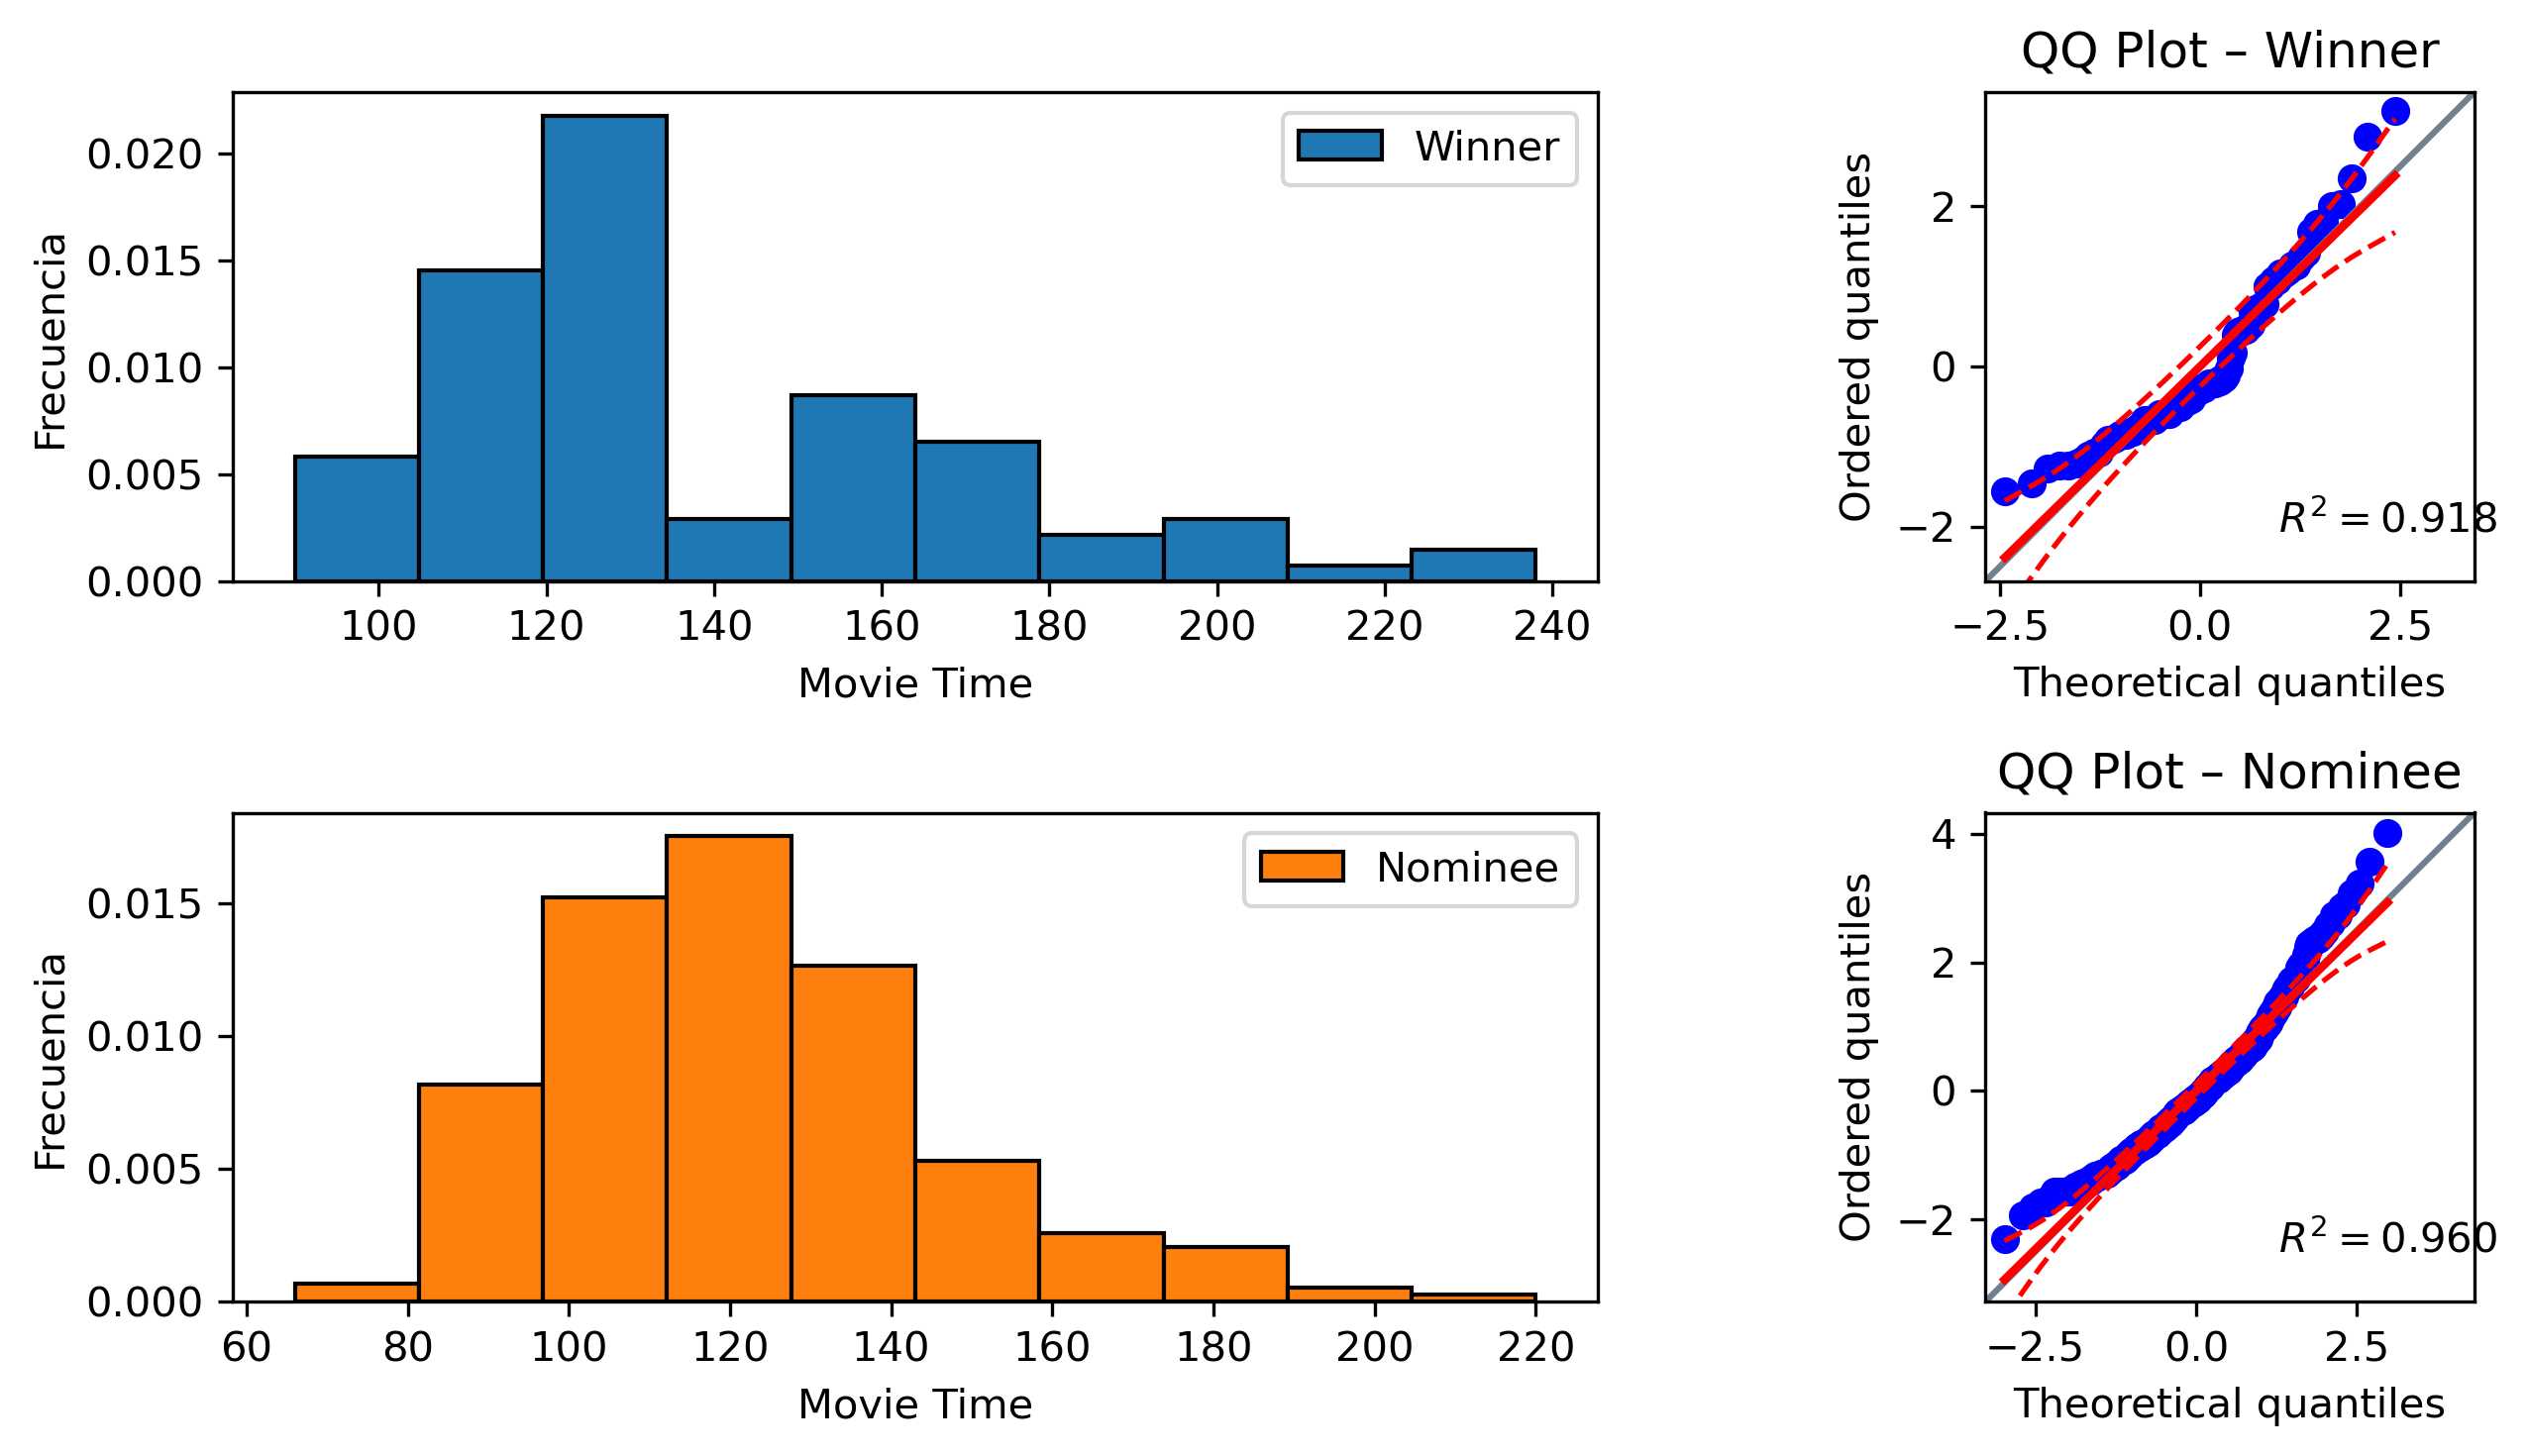

In [ ]:
# P4 - Movie Time por Award


rating = oscar_df['Award'].unique()
fig, ax = plt.subplots(2, 2, dpi=300, figsize=(10, 5))
colores = ['tab:blue', 'tab:orange']

for posi, awd in enumerate(rating):
    data = oscar_df[oscar_df['Award'] == awd]['Movie Time'].dropna()
    ax[posi, 0].hist(data, density=True, label=awd, facecolor=colores[posi], edgecolor='black')
    ax[posi, 0].set_xlabel('Movie Time')
    ax[posi, 0].set_ylabel('Frecuencia')
    ax[posi, 0].legend()
    pg.qqplot(data, dist='norm', confidence=0.95, ax=ax[posi, 1])
    ax[posi, 1].set_title(f'QQ Plot - {awd}')

fig.tight_layout()
plt.show()

---
# 3. Mini Tutorial

En esta sección encontrarás mini tutoriales sobre las funciones más utilizadas en el curso.
Está organizado por librería para facilitar la búsqueda.

## 3.1 Pandas – Carga y exploración de datos

In [35]:


# --- Cargar datos ---
df = pd.read_csv('archivo.csv')           # desde archivo local
df = pd.read_csv('url?raw=True')          # desde URL (GitHub, etc.)

# --- Primeras miradas ---
df.head(5)          # primeras 5 filas
df.tail(5)          # últimas 5 filas
df.shape            # (filas, columnas)
df.info()           # tipos de datos y nulos
df.describe()       # estadísticas descriptivas de columnas numéricas
df.columns          # nombres de columnas

FileNotFoundError: [Errno 2] No such file or directory: 'archivo.csv'

### Filtrado y selección

In [ ]:
# Seleccionar columnas
df['columna']                          # una columna → Serie
df[['col1', 'col2']]                   # varias columnas → DataFrame

# Filtrar filas con condición booleana
df[df['col'] > 10]
df[(df['col1'] == 'A') & (df['col2'] > 5)]   # AND
df[(df['col1'] == 'A') | (df['col2'] > 5)]   # OR

# Filtrar con .str (para texto)
df[df['col'].str.contains('palabra')]         # contiene subcadena
df[df['col'].str.startswith('inicio')]        # empieza con

# Seleccionar por índice
df.loc[0:5, 'col']         # por etiqueta
df.iloc[0:5, 0:3]          # por posición entera

### Agrupación y estadísticas

In [ ]:
# groupby + describe
df.groupby('categoria')['valor'].describe()

# groupby + agregaciones personalizadas
df.groupby('categoria').agg(
    media   = ('valor', 'mean'),
    mediana = ('valor', 'median'),
    std     = ('valor', 'std'),
    iqr     = ('valor', lambda x: x.quantile(0.75) - x.quantile(0.25))
)

# Conteo de valores únicos (muy útil para variables categóricas)
df['col'].value_counts()
df['col'].nunique()      # número de categorías
df['col'].unique()       # lista de categorías

### Limpieza de datos

In [ ]:
# Valores nulos
df.isnull().sum()           # cantidad de nulos por columna
df.dropna()                 # eliminar filas con cualquier nulo
df.dropna(subset=['col'])   # solo si esa columna es nula
df.fillna(0)                # reemplazar nulos por 0

# Conversión de tipos
df['col'] = df['col'].astype(int)
df['col'] = df['col'].str.replace(',', '').astype(float)

# Renombrar columnas
df.rename(columns={'nombre_viejo': 'nombre_nuevo'}, inplace=True)

## 3.2 Matplotlib – Visualización básica

In [ ]:


fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

# Histograma
ax.hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='white')

# Líneas verticales (media, mediana)
ax.axvline(np.mean(data), color='red',   linestyle='--', linewidth=1.5, label='Media')
ax.axvline(np.median(data), color='green', linestyle='--', linewidth=1.5, label='Mediana')

# Decoración
ax.set_xlabel('Variable')
ax.set_ylabel('Densidad')
ax.set_title('Título del gráfico')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Múltiples subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

axes[0].hist(data, bins=20, color='steelblue')
axes[0].set_title('Histograma')

axes[1].boxplot(data, vert=True, patch_artist=True)
axes[1].set_title('Boxplot')

fig.suptitle('Título general')   # título para toda la figura
fig.tight_layout()
plt.show()

## 3.3 Seaborn – Visualización estadística

In [ ]:


# Boxplot agrupado (muy útil para comparar distribuciones)
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
sns.boxplot(data=df, x='categoria', y='valor', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

# KDE plot (estimación de densidad) — ideal para comparar grupos
fig, ax = plt.subplots(figsize=(8, 4), dpi=150)
sns.kdeplot(data=df, x='valor', hue='categoria', fill=True, ax=ax)
plt.show()

# Violinplot: combina boxplot + KDE
sns.violinplot(data=df, x='categoria', y='valor')
plt.show()

## 3.4 Pingouin – Estadística y QQ Plots

`pingouin` es una librería de estadística en Python diseñada para ser más **legible e intuitiva** que `statsmodels`. Usaremos principalmente su función `qqplot` para evaluar normalidad.

In [ ]:


# --- QQ Plot básico ---
# Genera automáticamente la banda de confianza al 95%
data_normal   = np.random.normal(0, 1, 500)
data_sesgado  = np.random.exponential(1, 500)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=150)

pg.qqplot(data_normal,  dist='norm', confidence=0.95, ax=axes[0])
axes[0].set_title('Datos normales')

pg.qqplot(data_sesgado, dist='norm', confidence=0.95, ax=axes[1])
axes[1].set_title('Datos sesgados')

fig.tight_layout()
plt.show()

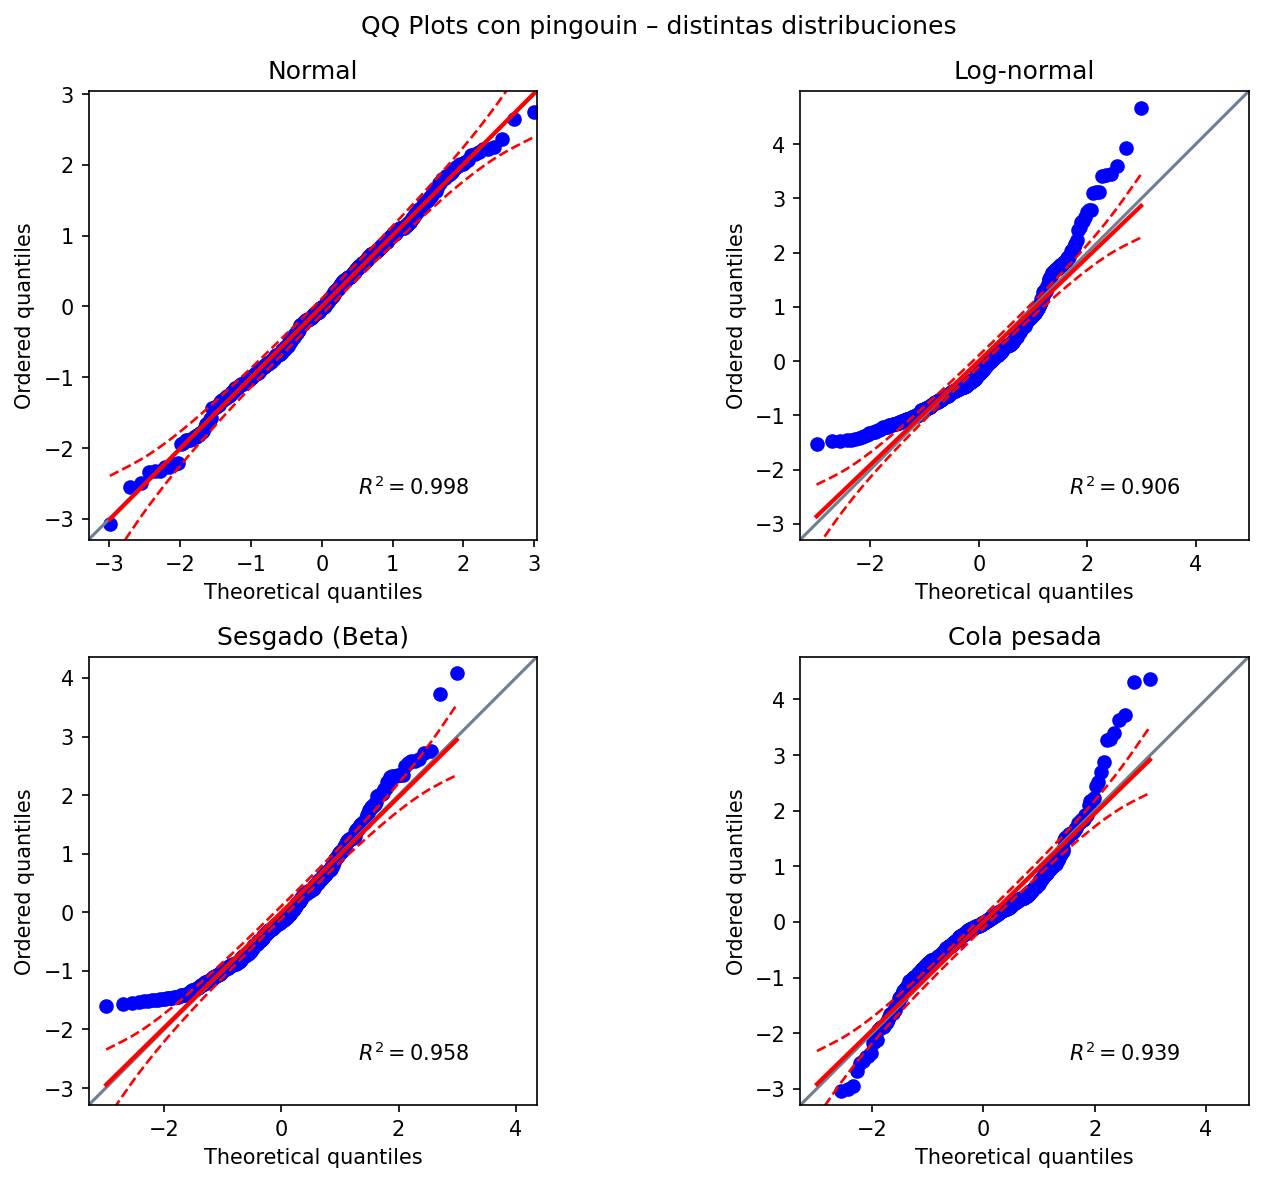

In [ ]:
# --- Comparar QQ plots de distintas distribuciones ---


distribuciones = {
    'Normal':         np.random.normal(0, 1, 500),
    'Log-normal':     np.random.lognormal(0, 0.5, 500),
    'Sesgado (Beta)': stats.beta(2, 8).rvs(500),
    'Cola pesada':    stats.laplace().rvs(500),
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8), dpi=150)
for ax, (nombre, data) in zip(axes.flat, distribuciones.items()):
    pg.qqplot(data, dist='norm', confidence=0.95, ax=ax)
    ax.set_title(nombre)

fig.suptitle('QQ Plots con pingouin distintas distribuciones')
fig.tight_layout()
plt.show()